In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Smart Sustainable Meal Optimizer")
print("Python environment is working!")

Smart Sustainable Meal Optimizer
Python environment is working!


In [5]:
%pip install pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\albab\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Smart Sustainable Meal Optimizer")
print("Python environment is working!")

Smart Sustainable Meal Optimizer
Python environment is working!


In [7]:
import pandas as pd

food_data = pd.read_csv("../data/raw/sample_food_data.csv")

food_data.head()


,food,calories,protein_g,carbs_g,fat_g,cost_per_serving,ghg_kg_co2e
0,Chicken breast,187,35,0,4,1.80,2.5
1,Lentils,230,18,40,1,0.45,0.9
2,Black beans,227,15,41,1,0.40,0.8
3,Brown rice,216,5,45,2,0.30,0.7
4,Eggs,143,13,1,10,0.35,1.8


In [1]:
import pandas as pd

food_data = pd.read_csv("../data/raw/food.csv")

food_data.head()

,fdc_id,data_type,description,food_category_id,publication_date
0,319874,sample_food,"HUMMUS, SABRA CLASSIC",16.0,2019-04-01
1,319875,market_acquisition,"HUMMUS, SABRA CLASSIC",16.0,2019-04-01
2,319876,market_acquisition,"HUMMUS, SABRA CLASSIC",16.0,2019-04-01
3,319877,sub_sample_food,Hummus,16.0,2019-04-01
4,319878,sub_sample_food,Hummus,16.0,2019-04-01


In [2]:
print("Shape:", food_data.shape)

print("\nColumn names:")
print(food_data.columns.tolist())

print("\nData types:")
print(food_data.dtypes)

Shape: (87990, 5)

Column names:
['fdc_id', 'data_type', 'description', 'food_category_id', 'publication_date']

Data types:
fdc_id                int64
data_type               str
description             str
food_category_id    float64
publication_date        str
dtype: object


In [9]:
print("Shape:", food_data.shape)
print("\nColumn names:")
print(food_data.columns.tolist())

print("\nData types:")
print(food_data.dtypes)

Shape: (10, 7)

Column names:
['food', 'calories', 'protein_g', 'carbs_g', 'fat_g', 'cost_per_serving', 'ghg_kg_co2e']

Data types:
food                    str
calories              int64
protein_g             int64
carbs_g               int64
fat_g                 int64
cost_per_serving    float64
ghg_kg_co2e         float64
dtype: object


In [10]:
food_data.describe()

,calories,protein_g,carbs_g,fat_g,cost_per_serving,ghg_kg_co2e
count,10.000000,10.000000,10.000000,10.000000,10.00000,10.000000
mean,172.100000,13.600000,20.500000,4.400000,0.77000,1.270000
std,53.504828,9.800227,19.242603,4.575296,0.76092,1.017677
min,55.000000,4.000000,0.000000,0.000000,0.25000,0.400000
25%,145.500000,5.000000,1.500000,1.000000,0.31250,0.625000
50%,174.000000,14.000000,19.000000,2.500000,0.42500,0.850000
75%,214.000000,17.750000,39.250000,7.750000,0.71250,1.600000
max,230.000000,35.000000,45.000000,13.000000,2.50000,3.500000


### Initial Data Quality Observations

The sample dataset contains food items with information about nutrition, cost and environmental impact. The columns have consistent names and numerical values can be used for analysis. I will need to check for missing values, duplicate foods and consistent units when I work with the full datasets.

In [3]:
nutrient_data = pd.read_csv("../data/raw/food_nutrient.csv")

print("Shape:", nutrient_data.shape)

print("\nColumn names:")
print(nutrient_data.columns.tolist())

nutrient_data.head()

Shape: (170469, 11)

Column names:
['id', 'fdc_id', 'nutrient_id', 'amount', 'data_points', 'derivation_id', 'min', 'max', 'median', 'footnote', 'min_year_acquired']


C:\Users\albab\AppData\Local\Temp\ipykernel_25548\279840074.py:1: DtypeWarning: Columns (9: footnote) have mixed types. Specify dtype option on import or set low_memory=False.
  nutrient_data = pd.read_csv("../data/raw/food_nutrient.csv")


,id,fdc_id,nutrient_id,amount,data_points,derivation_id,min,max,median,footnote,min_year_acquired
0,2201847,319877,1051,56.30,1.0,1.0,NaN,NaN,NaN,NaN,NaN
1,2201845,319877,1002,1.28,1.0,1.0,NaN,NaN,NaN,NaN,NaN
2,2201846,319877,1004,19.00,1.0,1.0,NaN,NaN,NaN,NaN,NaN
3,2201844,319877,1007,1.98,1.0,1.0,NaN,NaN,NaN,NaN,NaN
4,2201852,319878,1091,188.00,1.0,1.0,NaN,NaN,NaN,NaN,NaN


In [4]:
nutrient_info = pd.read_csv("../data/raw/nutrient.csv")

print("Shape:", nutrient_info.shape)

print("\nColumn names:")
print(nutrient_info.columns.tolist())

nutrient_info.head()

Shape: (477, 5)

Column names:
['id', 'name', 'unit_name', 'nutrient_nbr', 'rank']


,id,name,unit_name,nutrient_nbr,rank
0,2047,Energy (Atwater General Factors),KCAL,957.0,280.0
1,2048,Energy (Atwater Specific Factors),KCAL,958.0,290.0
2,1001,Solids,G,201.0,200.0
3,1002,Nitrogen,G,202.0,500.0
4,1003,Protein,G,203.0,600.0


In [5]:
nutrient_info[
    nutrient_info["name"].str.contains(
        "Energy|Protein|Carbohydrate|Total lipid", 
        case=False, 
        na=False
    )
][["id", "name", "unit_name"]]

,id,name,unit_name
0,2047,Energy (Atwater General Factors),KCAL
1,2048,Energy (Atwater Specific Factors),KCAL
4,1003,Protein,G
5,1004,Total lipid (fat),G
6,1005,"Carbohydrate, by difference",G
9,1008,Energy,KCAL
51,1050,"Carbohydrate, by summation",G
54,1053,Adjusted Protein,G
63,1062,Energy,kJ
73,1072,"Carbohydrate, other",G


In [6]:
# Check how many records have the nutrients we need
needed_nutrients = [1003, 1004, 1005, 1008]

nutrition_check = nutrient_data[
    nutrient_data["nutrient_id"].isin(needed_nutrients)
]

print("Nutrition records:", len(nutrition_check))
print("Unique foods with these nutrients:", nutrition_check["fdc_id"].nunique())

Nutrition records: 6678
Unique foods with these nutrients: 4821


In [7]:
# Count how many of the 4 nutrients each food has
nutrient_counts = nutrition_check.groupby("fdc_id")["nutrient_id"].nunique()

print(nutrient_counts.value_counts().sort_index())

nutrient_id
1    3476
2     968
3     242
4     135
Name: count, dtype: int64


In [8]:
# Check how many foods have both calories and protein
main_nutrients = [1003, 1008]

main_nutrition_check = nutrient_data[
    nutrient_data["nutrient_id"].isin(main_nutrients)
]

main_counts = main_nutrition_check.groupby("fdc_id")["nutrient_id"].nunique()

print("Foods with both calories and protein:", (main_counts == 2).sum())

Foods with both calories and protein: 135


In [9]:
sr_food = pd.read_csv("../data/raw/sr_legacy/food.csv")

sr_nutrient = pd.read_csv("../data/raw/sr_legacy/food_nutrient.csv")

sr_nutrient_info = pd.read_csv("../data/raw/sr_legacy/nutrient.csv")

print("Foods:", sr_food.shape)
print("Nutrition records:", sr_nutrient.shape)
print("Nutrient definitions:", sr_nutrient_info.shape)

Foods: (7793, 5)
Nutrition records: (644125, 11)
Nutrient definitions: (474, 5)


In [10]:
# Find the nutrient IDs for calories, protein, fat and carbohydrates
sr_nutrient_info[
    sr_nutrient_info["name"].str.contains(
        "Energy|Protein|Carbohydrate|Total lipid",
        case=False,
        na=False
    )
][["id", "name", "unit_name"]]

,id,name,unit_name
0,2047,Energy (Atwater General Factors),KCAL
1,2048,Energy (Atwater Specific Factors),KCAL
4,1003,Protein,G
5,1004,Total lipid (fat),G
6,1005,"Carbohydrate, by difference",G
9,1008,Energy,KCAL
51,1050,"Carbohydrate, by summation",G
54,1053,Adjusted Protein,G
63,1062,Energy,kJ
73,1072,"Carbohydrate, other",G


In [11]:
sr_needed_nutrients = [1003, 1004, 1005, 1008]

sr_nutrition_check = sr_nutrient[
    sr_nutrient["nutrient_id"].isin(sr_needed_nutrients)
]

print("Nutrition records:", len(sr_nutrition_check))
print("Unique foods:", sr_nutrition_check["fdc_id"].nunique())

sr_counts = sr_nutrition_check.groupby("fdc_id")["nutrient_id"].nunique()

print("\nNumber of nutrients per food:")
print(sr_counts.value_counts().sort_index())

Nutrition records: 31172
Unique foods: 7793

Number of nutrients per food:
nutrient_id
4    7793
Name: count, dtype: int64


In [12]:
print("Missing values in food data:")
print(sr_food.isnull().sum())

print("\nMissing values in nutrition data:")
print(sr_nutrient.isnull().sum())

Missing values in food data:
fdc_id              0
data_type           0
description         0
food_category_id    0
publication_date    0
dtype: int64

Missing values in nutrition data:
id                        0
fdc_id                    0
nutrient_id               0
amount                    0
data_points               0
derivation_id        181743
min                  547234
max                  547232
median               644125
footnote             643861
min_year_acquired    644125
dtype: int64


### Missing Values

The SR Legacy food table does not contain missing values in its main identification fields. The nutrition table has no missing values in the `amount` column, which contains the nutrient measurements needed for this project. Several supporting columns have substantial missing values, including `derivation_id`, `min`, `max`, `median`, `footnote`, and `min_year_acquired`. These fields are not necessary for the MVP, so I will not impute values for them. I plan to remove unnecessary columns during the cleaning process while keeping the nutrient amount data needed for analysis.

In [13]:
print("Duplicate rows in food data:", sr_food.duplicated().sum())
print("Duplicate rows in nutrition data:", sr_nutrient.duplicated().sum())

Duplicate rows in food data: 0
Duplicate rows in nutrition data: 0


In [14]:
# Check for negative nutrition values
main_nutrients = sr_nutrient[
    sr_nutrient["nutrient_id"].isin([1003, 1004, 1005, 1008])
]

print("Negative nutrition values:")
print((main_nutrients["amount"] < 0).sum())

Negative nutrition values:
0


In [15]:
# Summary statistics for the four main nutrients
main_nutrients = sr_nutrient[
    sr_nutrient["nutrient_id"].isin([1003, 1004, 1005, 1008])
]

print(main_nutrients.groupby("nutrient_id")["amount"].describe())

              count        mean         std  min    25%     50%     75%  \
nutrient_id                                                               
1003         7793.0   11.926873   10.859968  0.0   2.27    8.98   20.77   
1004         7793.0   10.687361   16.381682  0.0   0.80    5.06   13.50   
1005         7793.0   19.569788   25.705634  0.0   0.00    7.60   27.12   
1008         7793.0  220.243118  168.752033  0.0  91.00  183.00  317.00   

                max  
nutrient_id          
1003          88.32  
1004         100.00  
1005         100.00  
1008         902.00  


### Outlier Check

The summary statistics show some high values, including up to 88.32 grams of protein, 100 grams of fat, 100 grams of carbohydrates, and 902 calories. These values were not automatically removed because they may represent legitimate foods. Since the dataset does not show obvious negative or impossible values in the selected nutrition variables, I will keep these observations and investigate unusual values further if they affect the analysis.

In [16]:
sr_food[["fdc_id", "description"]].head(20)

,fdc_id,description
0,167512,"Pillsbury Golden Layer Buttermilk Biscuits, Ar..."
1,167513,"Pillsbury, Cinnamon Rolls with Icing, refriger..."
2,167514,"Kraft Foods, Shake N Bake Original Recipe, Coa..."
3,167515,"George Weston Bakeries, Thomas English Muffins"
4,167516,"Waffles, buttermilk, frozen, ready-to-heat"
5,167517,"Waffle, buttermilk, frozen, ready-to-heat, toa..."
6,167518,"Waffle, buttermilk, frozen, ready-to-heat, mic..."
7,167519,"Waffle, plain, frozen, ready-to-heat, microwave"
8,167520,"Pie Crust, Cookie-type, Graham Cracker, Ready ..."
9,167521,"Pie Crust, Cookie-type, Chocolate, Ready Crust"


In [17]:
sr_portion = pd.read_csv("../data/raw/sr_legacy/food_portion.csv")

print("Shape:", sr_portion.shape)

print("\nColumn names:")
print(sr_portion.columns.tolist())

sr_portion.head()

Shape: (14449, 11)

Column names:
['id', 'fdc_id', 'seq_num', 'amount', 'measure_unit_id', 'portion_description', 'modifier', 'gram_weight', 'data_points', 'footnote', 'min_year_acquired']


,id,fdc_id,seq_num,amount,measure_unit_id,portion_description,modifier,gram_weight,data_points,footnote,min_year_acquired
0,81549,167512,1,1.0,9999,NaN,serving,34.0,NaN,NaN,NaN
1,81550,167513,1,1.0,9999,NaN,serving 1 roll with icing,44.0,1.0,NaN,NaN
2,81551,167514,1,1.0,9999,NaN,serving,28.0,NaN,NaN,NaN
3,81552,167515,1,1.0,9999,NaN,serving,57.0,NaN,NaN,NaN
4,81553,167516,1,1.0,9999,NaN,"waffle, square",39.0,10.0,NaN,NaN


In [18]:
print("Foods in SR Legacy:", sr_food["fdc_id"].nunique())
print("Foods with portion information:", sr_portion["fdc_id"].nunique())

Foods in SR Legacy: 7793
Foods with portion information: 7533


In [19]:
sr_nutrient_info[
    sr_nutrient_info["id"].isin([1003, 1004, 1005, 1008])
][["id", "name", "unit_name"]]

,id,name,unit_name
4,1003,Protein,G
5,1004,Total lipid (fat),G
6,1005,"Carbohydrate, by difference",G
9,1008,Energy,KCAL


In [20]:
# Keep only the four nutrients needed for the MVP
selected_nutrients = sr_nutrient[
    sr_nutrient["nutrient_id"].isin([1003, 1004, 1005, 1008])
].copy()

selected_nutrients.head()

,id,fdc_id,nutrient_id,amount,data_points,derivation_id,min,max,median,footnote,min_year_acquired
0,1283674,167512,1003,5.88,1,46.0,NaN,NaN,NaN,NaN,NaN
9,1283683,167512,1004,13.24,1,46.0,NaN,NaN,NaN,NaN,NaN
10,1283684,167512,1005,41.18,0,49.0,NaN,NaN,NaN,NaN,NaN
11,1283685,167512,1008,307.00,0,49.0,NaN,NaN,NaN,NaN,NaN
14,1283688,167513,1003,4.34,1,47.0,NaN,NaN,NaN,NaN,NaN


In [21]:
# Create one row per food with separate nutrition columns
nutrition_wide = selected_nutrients.pivot(
    index="fdc_id",
    columns="nutrient_id",
    values="amount"
).reset_index()

nutrition_wide = nutrition_wide.rename(columns={
    1003: "protein_g",
    1004: "fat_g",
    1005: "carbs_g",
    1008: "calories"
})

nutrition_wide.head()

nutrient_id,fdc_id,protein_g,fat_g,carbs_g,calories
0,167512,5.88,13.24,41.18,307.0
1,167513,4.34,11.27,53.42,330.0
2,167514,6.10,3.70,79.80,377.0
3,167515,8.00,1.80,46.00,232.0
4,167516,6.58,9.22,41.05,273.0


In [22]:
nutrition_wide = nutrition_wide.merge(
    sr_food[["fdc_id", "description"]],
    on="fdc_id",
    how="left"
)

nutrition_wide.head()

,fdc_id,protein_g,fat_g,carbs_g,calories,description
0,167512,5.88,13.24,41.18,307.0,"Pillsbury Golden Layer Buttermilk Biscuits, Ar..."
1,167513,4.34,11.27,53.42,330.0,"Pillsbury, Cinnamon Rolls with Icing, refriger..."
2,167514,6.10,3.70,79.80,377.0,"Kraft Foods, Shake N Bake Original Recipe, Coa..."
3,167515,8.00,1.80,46.00,232.0,"George Weston Bakeries, Thomas English Muffins"
4,167516,6.58,9.22,41.05,273.0,"Waffles, buttermilk, frozen, ready-to-heat"


In [23]:
nutrition_wide.isnull().sum()

fdc_id         0
protein_g      0
fat_g          0
carbs_g        0
calories       0
description    0
dtype: int64

In [24]:
nutrition_wide.to_csv(
    "../data/processed/cleaned_nutrition.csv",
    index=False
)

In [25]:
nutrition_wide.shape

(7793, 6)

In [26]:
nutrition_wide[["calories", "protein_g"]].describe()

,calories,protein_g
count,7793.000000,7793.000000
mean,220.243118,11.926873
std,168.752033,10.859968
min,0.000000,0.000000
25%,91.000000,2.270000
50%,183.000000,8.980000
75%,317.000000,20.770000
max,902.000000,88.320000


<Axes: title={'center': 'Distribution of Calories Across Foods'}, xlabel='Calories', ylabel='Number of Foods'>

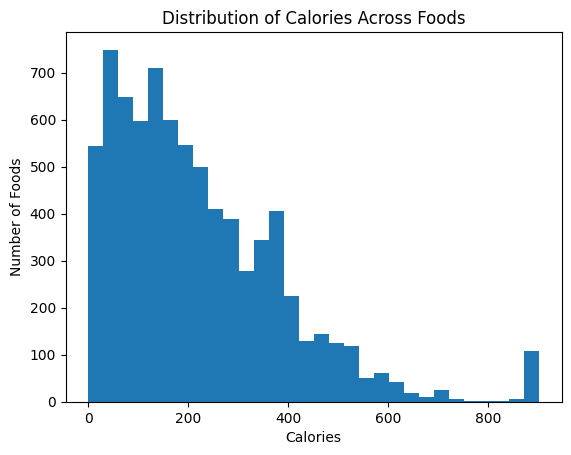

In [27]:
nutrition_wide["calories"].plot(
    kind="hist",
    bins=30,
    title="Distribution of Calories Across Foods",
    xlabel="Calories",
    ylabel="Number of Foods"
)

### Calorie Distribution

The calorie distribution is right-skewed, with most foods having lower to moderate calorie values and fewer foods having very high calorie values. The dataset includes foods ranging from 0 to 902 calories. This wide range could be useful for the meal optimizer because it provides food options with different calorie densities.

<Axes: title={'center': 'Distribution of Protein Across Foods'}, xlabel='Protein (g)', ylabel='Number of Foods'>

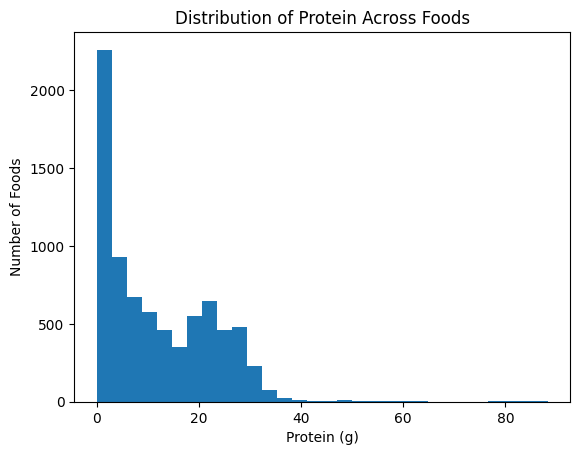

In [28]:
nutrition_wide["protein_g"].plot(
    kind="hist",
    bins=30,
    title="Distribution of Protein Across Foods",
    xlabel="Protein (g)",
    ylabel="Number of Foods"
)

### Protein Distribution

The protein distribution is right-skewed, with most foods containing lower amounts of protein and fewer foods containing high amounts. Protein ranges from 0 to 88.32 grams, with a median of 8.98 grams. This gives the meal optimizer a wide range of foods to compare when trying to meet a protein goal.

<Axes: title={'center': 'Relationship Between Calories and Protein'}, xlabel='Calories', ylabel='Protein (g)'>

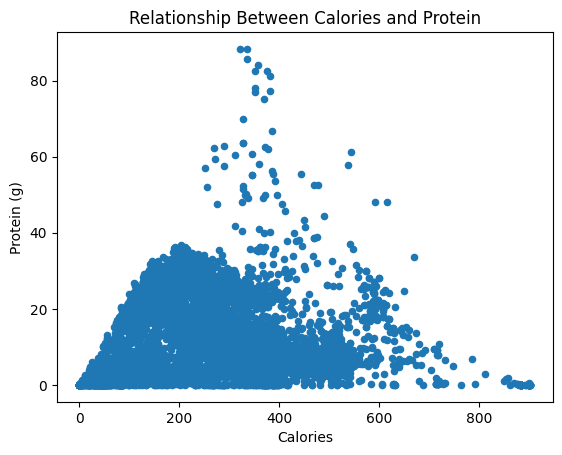

In [29]:
nutrition_wide.plot(
    kind="scatter",
    x="calories",
    y="protein_g",
    title="Relationship Between Calories and Protein",
    xlabel="Calories",
    ylabel="Protein (g)"
)

### Calories and Protein Relationship

The scatterplot shows that calories and protein do not have a simple linear relationship. Some foods with moderate calorie values provide relatively high amounts of protein, while some foods with higher calorie values contain little protein. This suggests that calories alone would not be enough to identify foods that meet a protein goal. The meal optimizer will need to consider multiple nutrition variables when creating recommendations.

In [30]:
nutrition_wide[["calories", "protein_g", "fat_g", "carbs_g"]].corr()

,calories,protein_g,fat_g,carbs_g
calories,1.000000,0.126493,0.825527,0.434860
protein_g,0.126493,1.000000,0.055735,-0.308815
fat_g,0.825527,0.055735,1.000000,-0.075165
carbs_g,0.434860,-0.308815,-0.075165,1.000000


### Correlation Analysis

The correlation results show that calories have a strong positive relationship with fat (0.826) and a moderate positive relationship with carbohydrates (0.435). The relationship between calories and protein is much weaker (0.126), showing that higher-calorie foods do not necessarily provide more protein. Protein and carbohydrates have a moderate negative relationship (-0.309), while protein and fat have very little relationship (0.056). These results support the need to consider multiple nutrition factors when creating meal recommendations rather than relying on calories alone.

In [31]:
nutrition_wide.nlargest(
    10, "protein_g"
)[["description", "protein_g", "calories"]]

,description,protein_g,calories
6764,Soy protein isolate,88.32,335.0
6790,"Soy protein isolate, potassium type",88.32,321.0
2087,"Gelatins, dry powder, unsweetened",85.60,335.0
3383,"Egg, white, dried, stabilized, glucose reduced",84.08,357.0
508,"Seal, bearded (Oogruk), meat, dried (Alaska Na...",82.60,351.0
5915,"Egg, white, dried, powder, stabilized, glucose...",82.40,376.0
4692,"Egg, white, dried",81.10,382.0
5668,"Beverages, Protein powder whey based",78.13,352.0
547,"Steelhead trout, dried, flesh (Shoshone Bannock)",77.27,382.0
5914,"Egg, white, dried, flakes, stabilized, glucose...",76.92,351.0


### Highest-Protein Foods

The highest-protein foods in the dataset include soy protein isolate, gelatin, dried egg products, protein powder and dried meats. Some of these foods are highly concentrated protein sources rather than typical meal ingredients. This is a potential concern for the meal optimizer because simply maximizing protein could lead to unrealistic recommendations. I may need to limit the types of foods included in the final optimization or apply additional criteria when selecting foods.

In [32]:
nutrition_wide.dtypes

fdc_id           int64
protein_g      float64
fat_g          float64
carbs_g        float64
calories       float64
description        str
dtype: object

### Data Types

The cleaned nutrition dataset has appropriate data types for analysis. The food ID is stored as an integer, the nutrition variables are numeric, and the food description is stored as text. No data type changes are needed at this point.

In [33]:
environmental = pd.read_excel(
    "../data/raw/environmental/dataFIELDv1.0.xlsx"
)

environmental.head()

ImportError: `Import openpyxl` failed.  Use pip or conda to install the openpyxl package.

In [34]:
%pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpy


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\albab\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
environmental = pd.read_excel(
    "../data/raw/environmental/dataFIELDv1.0.xlsx"
)

environmental.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18
0,Welcome to dataFIELD version 1.0 - (database o...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,This version links greenhouse gas emissions (G...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://fcid.foodrisk.org/
2,NaN,FCID commodity codes can then be used to link ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,The methods used to compile this database are ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,"Heller MC, Willits-Smith A, Meyer R, Keoleian ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
excel_file = pd.ExcelFile(
    "../data/raw/environmental/dataFIELDv1.0.xlsx"
)

excel_file.sheet_names

['DESCRIPTION',
 'FCID linkages',
 'literature entries',
 'Pivot Table_GHG',
 'Pivot Table_CED',
 "PROXY def'ns",
 'MassConv']

In [4]:
environmental_ghg = pd.read_excel(
    "../data/raw/environmental/dataFIELDv1.0.xlsx",
    sheet_name="Pivot Table_GHG"
)

environmental_ghg.head()

C:\Users\albab\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19
0,NaN,NaN,FARM GATE,NaN,NaN,NaN,NaN,PROCESSOR GATE,NaN,NaN,NaN,NaN,TOTAL LIFE CYCLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,Values,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,FOOD TYPE,SUB TYPE,"Count of ACTIVE GHGE, FARM GATE (kg CO2e/kg)","Average of ACTIVE GHGE, FARM GATE (kg CO2e...","Min of ACTIVE GHGE, FARM GATE (kg CO2e/kg)","Max of ACTIVE GHGE, FARM GATE (kg CO2e/kg)","StdDev of ACTIVE GHGE, FARM GATE (kg CO2e/kg)","Count of GHGE, processor gate (kg CO2e/kg)","Average of GHGE, processor gate (kg CO2e/kg)","Min of GHGE, processor gate (kg CO2e/kg)","Max of GHGE, processor gate (kg CO2e/kg)","StdDev of GHGE, processor gate (kg CO2e/kg)","Count of GHGE, TOTAL LC (kg CO2e/kg)","Average of GHGE, TOTAL LC (kg CO2e/kg)","Min of GHGE, TOTAL LC (kg CO2e/kg)","Max of GHGE, TOTAL LC (kg CO2e/kg)","StdDev of GHGE, TOTAL LC (kg CO2e/kg)",NaN,NaN,NaN
3,Beverages,Beer,26,0.166747,0.044835,0.335891,0.089084,24,0.314906,0.065386,0.859406,0.258886,26,0.691948,0.091228,1.483168,0.409508,NaN,NaN,NaN
4,NaN,Carbonated Drinks,6,0.038388,0.038388,0.038388,0,6,0.066059,0.049904,0.092131,0.017236,17,0.475253,0.116326,1.046938,0.311374,NaN,NaN,NaN


In [7]:
environmental_ghg = pd.read_excel(
    "../data/raw/environmental/dataFIELDv1.0.xlsx",
    sheet_name="Pivot Table_GHG",
    skiprows=2
)

environmental_ghg.head()

C:\Users\albab\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,Unnamed: 0,Unnamed: 1,Values,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19
0,FOOD TYPE,SUB TYPE,"Count of ACTIVE GHGE, FARM GATE (kg CO2e/kg)","Average of ACTIVE GHGE, FARM GATE (kg CO2e...","Min of ACTIVE GHGE, FARM GATE (kg CO2e/kg)","Max of ACTIVE GHGE, FARM GATE (kg CO2e/kg)","StdDev of ACTIVE GHGE, FARM GATE (kg CO2e/kg)","Count of GHGE, processor gate (kg CO2e/kg)","Average of GHGE, processor gate (kg CO2e/kg)","Min of GHGE, processor gate (kg CO2e/kg)","Max of GHGE, processor gate (kg CO2e/kg)","StdDev of GHGE, processor gate (kg CO2e/kg)","Count of GHGE, TOTAL LC (kg CO2e/kg)","Average of GHGE, TOTAL LC (kg CO2e/kg)","Min of GHGE, TOTAL LC (kg CO2e/kg)","Max of GHGE, TOTAL LC (kg CO2e/kg)","StdDev of GHGE, TOTAL LC (kg CO2e/kg)",NaN,NaN,NaN
1,Beverages,Beer,26,0.166747,0.044835,0.335891,0.089084,24,0.314906,0.065386,0.859406,0.258886,26,0.691948,0.091228,1.483168,0.409508,NaN,NaN,NaN
2,NaN,Carbonated Drinks,6,0.038388,0.038388,0.038388,0,6,0.066059,0.049904,0.092131,0.017236,17,0.475253,0.116326,1.046938,0.311374,NaN,NaN,NaN
3,NaN,"Coffee, brewed",1,0.38,0.38,0.38,NaN,0,NaN,0,0,NaN,4,0.804688,0.380408,1.21,0.411447,NaN,NaN,NaN
4,NaN,"Coffee, Instant",1,7.75,7.75,7.75,NaN,2,19.2,11.35,27.05,11.101576,2,37.225,35,39.45,3.146625,NaN,NaN,NaN


In [8]:
environmental_ghg = pd.read_excel(
    "../data/raw/environmental/dataFIELDv1.0.xlsx",
    sheet_name="Pivot Table_GHG",
    skiprows=3
)

environmental_ghg.head()

C:\Users\albab\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,FOOD TYPE,SUB TYPE,"Count of ACTIVE GHGE, FARM GATE (kg CO2e/kg)","Average of ACTIVE GHGE, FARM GATE (kg CO2e/kg)","Min of ACTIVE GHGE, FARM GATE (kg CO2e/kg)","Max of ACTIVE GHGE, FARM GATE (kg CO2e/kg)","StdDev of ACTIVE GHGE, FARM GATE (kg CO2e/kg)","Count of GHGE, processor gate (kg CO2e/kg)","Average of GHGE, processor gate (kg CO2e/kg)","Min of GHGE, processor gate (kg CO2e/kg)","Max of GHGE, processor gate (kg CO2e/kg)","StdDev of GHGE, processor gate (kg CO2e/kg)","Count of GHGE, TOTAL LC (kg CO2e/kg)","Average of GHGE, TOTAL LC (kg CO2e/kg)","Min of GHGE, TOTAL LC (kg CO2e/kg)","Max of GHGE, TOTAL LC (kg CO2e/kg)","StdDev of GHGE, TOTAL LC (kg CO2e/kg)",Unnamed: 17,Unnamed: 18,Unnamed: 19
0,Beverages,Beer,26.0,0.166747,0.044835,0.335891,0.089084,24.0,0.314906,0.065386,0.859406,0.258886,26.0,0.691948,0.091228,1.483168,0.409508,NaN,NaN,NaN
1,NaN,Carbonated Drinks,6.0,0.038388,0.038388,0.038388,0.000000,6.0,0.066059,0.049904,0.092131,0.017236,17.0,0.475253,0.116326,1.046938,0.311374,NaN,NaN,NaN
2,NaN,"Coffee, brewed",1.0,0.380000,0.380000,0.380000,NaN,0.0,NaN,0.000000,0.000000,NaN,4.0,0.804688,0.380408,1.210000,0.411447,NaN,NaN,NaN
3,NaN,"Coffee, Instant",1.0,7.750000,7.750000,7.750000,NaN,2.0,19.200000,11.350000,27.050000,11.101576,2.0,37.225000,35.000000,39.450000,3.146625,NaN,NaN,NaN
4,NaN,"Coffee, roasted bean",2.0,3.567806,2.874074,4.261538,0.981085,3.0,6.279080,3.288889,10.671429,3.885873,3.0,12.608022,8.600000,16.676923,4.038806,NaN,NaN,NaN


In [9]:
environmental_ghg["FOOD TYPE"] = environmental_ghg["FOOD TYPE"].ffill()

environmental_ghg[["FOOD TYPE", "SUB TYPE"]].head(20)

,FOOD TYPE,SUB TYPE
0,Beverages,Beer
1,Beverages,Carbonated Drinks
2,Beverages,"Coffee, brewed"
3,Beverages,"Coffee, Instant"
4,Beverages,"Coffee, roasted bean"
5,Beverages,"Grape, wine and sherry"
6,Beverages,"Lemon, juice"
7,Beverages,"Lemon, Juice, concentrate"
8,Beverages,liquor
9,Beverages,"Orange, Juice"


In [10]:
environmental_ghg = environmental_ghg[
    environmental_ghg["SUB TYPE"].notna()
].copy()

environmental_ghg[["FOOD TYPE", "SUB TYPE"]].tail(10)

,FOOD TYPE,SUB TYPE
246,Vegetables,"Tomato, juice"
247,Vegetables,"Tomato, paste"
248,Vegetables,"Tomato, peeled"
249,Vegetables,"Tomato, puree"
250,Vegetables,"Turnip, roots"
251,Vegetables,x_Lettuce
252,Vegetables,"Yam, true"
253,Vegetables,zucchini
254,Vegetables,"Zucchini, greenhouse"
256,(blank),(blank)


In [11]:
environmental_ghg = environmental_ghg[
    (environmental_ghg["SUB TYPE"].notna()) &
    (environmental_ghg["SUB TYPE"] != "(blank)")
].copy()

environmental_ghg[["FOOD TYPE", "SUB TYPE"]].tail()

,FOOD TYPE,SUB TYPE
250,Vegetables,"Turnip, roots"
251,Vegetables,x_Lettuce
252,Vegetables,"Yam, true"
253,Vegetables,zucchini
254,Vegetables,"Zucchini, greenhouse"


In [12]:
environmental_clean = environmental_ghg[
    [
        "FOOD TYPE",
        "SUB TYPE",
        "Average of GHGE, TOTAL LC (kg CO2e/kg)"
    ]
].copy()

environmental_clean.head()

,FOOD TYPE,SUB TYPE,"Average of GHGE, TOTAL LC (kg CO2e/kg)"
0,Beverages,Beer,0.691948
1,Beverages,Carbonated Drinks,0.475253
2,Beverages,"Coffee, brewed",0.804688
3,Beverages,"Coffee, Instant",37.225000
4,Beverages,"Coffee, roasted bean",12.608022


In [13]:
environmental_clean.isnull().sum()

FOOD TYPE                                  0
SUB TYPE                                   0
Average of GHGE, TOTAL LC (kg CO2e/kg)    71
dtype: int64

In [14]:
len(environmental_clean)

243

### Missing Environmental Data

The environmental dataset contains 243 food subtypes. The total life-cycle greenhouse gas emissions (GHGE) variable is missing for 71 subtypes, which is about 29.2% of the dataset. I decided not to replace these missing values with an average because doing so could create environmental impact values that were not provided by the original source. For the MVP, I will use the food subtypes that have available GHGE values and document the missing data as a limitation.

In [15]:
environmental_clean[
    environmental_clean["Average of GHGE, TOTAL LC (kg CO2e/kg)"].isna()
][["FOOD TYPE", "SUB TYPE"]].head(30)

,FOOD TYPE,SUB TYPE
17,Cereals and Grains,Barley
19,Cereals and Grains,Canola
21,Cereals and Grains,"Corn, field"
23,Cereals and Grains,"Corn, field, meal"
25,Cereals and Grains,"Millet, grain"
29,Cereals and Grains,Rapeseed
34,Cereals and Grains,"Rye, grain"
67,Fruit,Apricot
70,Fruit,"Blackberry, Andean"
73,Fruit,Cranberry


### Missing Environmental Data

The environmental dataset contains 243 food subtypes. The total life-cycle greenhouse gas emissions (GHGE) variable is missing for 71 subtypes, or about 29.2% of the dataset. The missing values include some common foods such as corn, lemon, mango and watermelon, so removing all missing rows could limit the foods available for the meal recommendation system. I will keep these rows during the initial cleaning and address the missing environmental values when I combine the environmental data with the nutrition data. Foods without an available environmental value will not be assigned an estimated value without additional justification.

In [16]:
environmental_clean.duplicated().sum()

np.int64(0)

In [17]:
environmental_clean[
    "Average of GHGE, TOTAL LC (kg CO2e/kg)"
].describe()

count    172.000000
mean       4.250581
std        8.665074
min       -0.050000
25%        0.694237
50%        1.587625
75%        3.392500
max       72.500000
Name: Average of GHGE, TOTAL LC (kg CO2e/kg), dtype: float64

In [18]:
environmental_clean[
    environmental_clean["Average of GHGE, TOTAL LC (kg CO2e/kg)"] < 0
]

,FOOD TYPE,SUB TYPE,"Average of GHGE, TOTAL LC (kg CO2e/kg)"
168,Oils and Fats,"x_Rapeseed, Oil",-0.05


### Unusual Environmental Values

The environmental dataset contained one negative greenhouse gas emissions value. Rapeseed oil had a value of -0.05 kg CO2e/kg. Because greenhouse gas emissions are being used as an environmental impact measure in this project, a negative value would not be meaningful for the analysis. I will exclude this observation from the cleaned environmental dataset rather than treating the negative value as a valid environmental impact.

In [19]:
environmental_clean = environmental_clean[
    environmental_clean["Average of GHGE, TOTAL LC (kg CO2e/kg)"] >= 0
].copy()

In [20]:
environmental_clean.shape

(171, 3)

In [21]:
environmental_clean[
    environmental_clean["Average of GHGE, TOTAL LC (kg CO2e/kg)"] == 
    environmental_clean["Average of GHGE, TOTAL LC (kg CO2e/kg)"].max()
]

,FOOD TYPE,SUB TYPE,"Average of GHGE, TOTAL LC (kg CO2e/kg)"
181,Other,"Essential Oil, orange",72.5


### Environmental Outlier Check

The environmental data contains a high value of 72.5 kg CO2e/kg for orange essential oil. This value is much higher than the median of 1.59 kg CO2e/kg, but it was not removed because an unusually high value does not necessarily indicate an error. The product is a concentrated essential oil rather than a typical whole food, which may help explain why its impact per kilogram is much higher. I will keep this observation but consider whether non-food products such as essential oils should be excluded when matching the environmental data to the nutrition dataset.

In [22]:
environmental_clean.to_csv(
    "../data/processed/cleaned_environmental.csv",
    index=False
)

In [23]:
environmental_clean.head()

,FOOD TYPE,SUB TYPE,"Average of GHGE, TOTAL LC (kg CO2e/kg)"
0,Beverages,Beer,0.691948
1,Beverages,Carbonated Drinks,0.475253
2,Beverages,"Coffee, brewed",0.804688
3,Beverages,"Coffee, Instant",37.225000
4,Beverages,"Coffee, roasted bean",12.608022


In [24]:
environmental_clean["FOOD TYPE"].value_counts()

FOOD TYPE
Vegetables            40
Fruit                 21
Dairy                 17
Beverages             16
Cereals and Grains    13
Other                 13
Legumes and Nuts      12
Meat                  10
Oils and Fats          9
Fish and Seafood       7
Meat Substitutes       7
Sweeteners             5
Eggs                   1
Name: count, dtype: int64

In [25]:
fcid_linkages = pd.read_excel(
    "../data/raw/environmental/dataFIELDv1.0.xlsx",
    sheet_name="FCID linkages"
)

fcid_linkages.shape

C:\Users\albab\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


(356, 32)

In [26]:
fcid_linkages.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,UTILIZED IMPACT FACTORS,Unnamed: 6,Unnamed: 7,Unnamed: 8,farm gate (=1),...,VARIANCE CALCULATIONS,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,NaN,NaN,NaN,NaN,number of times specific commodity appears in ...,CED,GHG,NaN,NaN,NaN,...,Energy Use (MJ/kg),NaN,NaN,NaN,NaN,GHGE,NaN,NaN,NaN,NaN
1,FCID_Code,FCID_Desc,Weight_Basis_ as defined by FCID,Comments (from FCID),N_Cases,MJ / kg,CO2 eq / kg,weight Conversion Factor,conversion factor source,or processor gate (=2)?,...,basis,n,proxy group mean,SD (group or indiv food),scaled SD (group SD*food mean/group mean),basis,n,proxy group mean,SD (group or indiv food),scaled SD (group SD*food mean/group mean)
2,101050000,"Beet, garden, roots",weight of roots; juice,NaN,659,1.221,0.19425,1.11,AgHB,1,...,roots,14,1.422071,0.57442,0.444325,roots,25,0.2134,0.17992,0.147545
3,101052000,"Beet, sugar",dry weight of sugar (sucrose),Sucrose is a disaccharide obtained from sugar ...,49979,4.574236,0.390783,1,FICRCD,2,...,sweeteners,14,8.845346,17.468328,9.03348,sweeteners,13,1.061186,1.8056,0.664914
4,101053000,"Beet, sugar, molasses",weight of molasses,NaN,7656,3.47585,0.287592,1,FICRCD,2,...,sweeteners,14,8.845346,17.468328,6.864321,sweeteners,13,1.061186,1.8056,0.489336


In [27]:
fcid_linkages[["FCID_Code", "FCID_Desc", "GHG"]].head(20)

KeyError: "None of [Index(['FCID_Code', 'FCID_Desc', 'GHG'], dtype='str')] are in the [columns]"

In [28]:
fcid_linkages = pd.read_excel(
    "../data/raw/environmental/dataFIELDv1.0.xlsx",
    sheet_name="FCID linkages",
    skiprows=1
)

C:\Users\albab\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [29]:
fcid_linkages.columns

Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3',
       'number of times specific commodity appears in FCID recipe files',
       'CED ', 'GHG ', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10',
       'PROXY?', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'PROXY?.1',
       'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Energy (MJ)',
       'GHG (kgCO2eq)', 'Unnamed: 21', 'Energy Use (MJ/kg)', 'Unnamed: 23',
       'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'GHGE', 'Unnamed: 28',
       'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31'],
      dtype='str')

In [30]:
fcid_linkages = pd.read_excel(
    "../data/raw/environmental/dataFIELDv1.0.xlsx",
    sheet_name="FCID linkages",
    header=2
)

C:\Users\albab\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [31]:
fcid_linkages.columns

Index(['FCID_Code', 'FCID_Desc', 'Weight_Basis_ as defined by FCID',
       'Comments (from FCID)', 'N_Cases', 'MJ / kg', 'CO2 eq / kg',
       'weight Conversion Factor', 'conversion factor source',
       ' or processor gate (=2)?', 'Unnamed: 10', 'Unnamed: 11',
       '# of datapoints', 'N-average', 'Std. Dev', 'Unnamed: 15',
       '# of datapoints.1', 'N-average.1', 'Std. Dev.1', 'Unnamed: 19',
       'Unnamed: 20', 'Unnamed: 21', 'basis', 'n', 'proxy group mean',
       'SD (group or indiv food)', 'scaled SD (group SD*food mean/group mean)',
       'basis.1', 'n.1', 'proxy group mean.1', 'SD (group or indiv food).1',
       'scaled SD (group SD*food mean/group mean).1'],
      dtype='str')

In [32]:
fcid_linkages[["FCID_Code", "FCID_Desc", "MJ / kg", "CO2 eq / kg"]].head(20)

,FCID_Code,FCID_Desc,MJ / kg,CO2 eq / kg
0,101050000,"Beet, garden, roots",1.221000,0.194250
1,101052000,"Beet, sugar",4.574236,0.390783
2,101053000,"Beet, sugar, molasses",3.475850,0.287592
3,101067000,Burdock,1.891355,0.283822
4,101078000,Carrot,1.325856,0.091616
5,101079000,"Carrot, juice",6.607856,1.070695
6,101100000,"Chicory, roots",0.154400,0.050446
7,101168000,"Ginseng, dried",0.000000,0.870000
8,101190000,Horseradish,1.422071,0.213400
9,101251000,Parsnip,1.621161,0.243276


In [33]:
fcid_linkages[["FCID_Code", "FCID_Desc", "MJ / kg", "CO2 eq / kg"]].isnull().sum()

FCID_Code      0
FCID_Desc      0
MJ / kg        0
CO2 eq / kg    0
dtype: int64

In [34]:
fcid_linkages.shape

(354, 32)

In [35]:
fcid_linkages["FCID_Desc"].head(100).tolist()

['Beet, garden, roots',
 'Beet, sugar',
 'Beet, sugar, molasses',
 'Burdock',
 'Carrot',
 'Carrot, juice',
 'Chicory, roots',
 'Ginseng, dried',
 'Horseradish',
 'Parsnip',
 'Radish, roots',
 'Radish, Oriental, roots',
 'Rutabaga',
 'Turnip, roots',
 'Arrowroot, flour',
 'Artichoke, Jerusalem',
 'Cassava',
 'Dasheen, corm',
 'Ginger',
 'Ginger, dried',
 'Potato, chips',
 'Potato, dry (granules/ flakes)',
 'Potato, flour',
 'Potato, tuber, w/peel',
 'Potato, tuber, w/o peel',
 'Sweet potato',
 'Tanier, corm',
 'Turmeric',
 'Yam, true',
 'Yam bean',
 'Beet, garden, tops',
 'Chicory, tops',
 'Dasheen, leaves',
 'Garlic, bulb',
 'Onion, bulb',
 'Onion, bulb, dried',
 'Shallot, bulb',
 'Chive, fresh leaves',
 'Leek',
 'Onion, green',
 'Amaranth, leafy',
 'Cilantro, leaves',
 'Dandelion, leaves',
 'Dillweed',
 'Endive',
 'Lettuce, head',
 'Lettuce, leaf',
 'Parsley, leaves',
 'Radicchio',
 'Spinach',
 'Swiss chard',
 'Arugula',
 'Broccoli, Chinese',
 'Cabbage, Chinese, bok choy',
 'Collards'

In [36]:
# Look at USDA foods containing some common environmental food names

common_foods = [
    "carrot",
    "broccoli",
    "tomato",
    "lentil",
    "chickpea",
    "black bean",
    "sweet potato",
    "potato",
    "soybean",
    "eggplant",
    "spinach"
]

for food in common_foods:
    matches = nutrition_wide[
        nutrition_wide["description"].str.contains(
            food, case=False, na=False
        )
    ]
    print(food, ":", len(matches))

NameError: name 'nutrition_wide' is not defined

In [37]:
nutrition_wide = pd.read_csv(
    "../data/processed/cleaned_nutrition.csv"
)

In [38]:
common_foods = [
    "carrot",
    "broccoli",
    "tomato",
    "lentil",
    "chickpea",
    "black bean",
    "sweet potato",
    "potato",
    "soybean",
    "eggplant",
    "spinach"
]

for food in common_foods:
    matches = nutrition_wide[
        nutrition_wide["description"].str.contains(
            food, case=False, na=False
        )
    ]
    print(food, ":", len(matches))

carrot : 27
broccoli : 20
tomato : 89
lentil : 9
chickpea : 8
black bean : 4
sweet potato : 26
potato : 155
soybean : 39
eggplant : 4
spinach : 25


In [39]:
whole_food_keywords = [
    # Protein
    "chicken breast",
    "chicken thigh",
    "turkey",
    "beef",
    "ground beef",
    "pork",
    "salmon",
    "tuna",
    "shrimp",
    "egg",
    "tofu",
    "tempeh",

    # Beans and legumes
    "black bean",
    "kidney bean",
    "pinto bean",
    "navy bean",
    "chickpea",
    "lentil",
    "split pea",

    # Grains
    "oat",
    "brown rice",
    "white rice",
    "quinoa",
    "barley",
    "whole wheat",
    "corn",

    # Vegetables
    "broccoli",
    "spinach",
    "carrot",
    "tomato",
    "cucumber",
    "bell pepper",
    "onion",
    "garlic",
    "cabbage",
    "cauliflower",
    "kale",
    "lettuce",
    "green bean",
    "pea",
    "sweet potato",
    "potato",
    "zucchini",
    "eggplant",
    "mushroom",

    # Fruit
    "apple",
    "banana",
    "orange",
    "grape",
    "strawberry",
    "blueberry",
    "raspberry",
    "blackberry",
    "mango",
    "pineapple",
    "watermelon",
    "peach",
    "pear",

    # Other basic foods
    "milk",
    "yogurt",
    "cheese",
    "peanut",
    "almond",
    "walnut",
    "avocado"
]

In [40]:
whole_foods = nutrition_wide[
    nutrition_wide["description"].str.contains(
        "|".join(whole_food_keywords),
        case=False,
        na=False
    )
].copy()

print("Number of matching foods:", len(whole_foods))

Number of matching foods: 3807


In [41]:
whole_foods[["fdc_id", "description"]].head(100)

,fdc_id,description
0,167512,"Pillsbury Golden Layer Buttermilk Biscuits, Ar..."
2,167514,"Kraft Foods, Shake N Bake Original Recipe, Coa..."
4,167516,"Waffles, buttermilk, frozen, ready-to-heat"
5,167517,"Waffle, buttermilk, frozen, ready-to-heat, toa..."
6,167518,"Waffle, buttermilk, frozen, ready-to-heat, mic..."
...,...,...
214,167726,"Babyfood, mixed fruit yogurt, strained"
216,167728,"Babyfood, rice and apples, dry"
217,167729,"Babyfood, juice, apple - cherry"
218,167730,"Milk, imitation, non-soy"


In [42]:
fcid_linkages[["FCID_Code", "FCID_Desc", "CO2 eq / kg"]].head(50)

,FCID_Code,FCID_Desc,CO2 eq / kg
0,101050000,"Beet, garden, roots",0.194250
1,101052000,"Beet, sugar",0.390783
2,101053000,"Beet, sugar, molasses",0.287592
3,101067000,Burdock,0.283822
4,101078000,Carrot,0.091616
5,101079000,"Carrot, juice",1.070695
6,101100000,"Chicory, roots",0.050446
7,101168000,"Ginseng, dried",0.870000
8,101190000,Horseradish,0.213400
9,101251000,Parsnip,0.243276


In [43]:
fcid_linkages["FCID_Desc"].tolist()

['Beet, garden, roots',
 'Beet, sugar',
 'Beet, sugar, molasses',
 'Burdock',
 'Carrot',
 'Carrot, juice',
 'Chicory, roots',
 'Ginseng, dried',
 'Horseradish',
 'Parsnip',
 'Radish, roots',
 'Radish, Oriental, roots',
 'Rutabaga',
 'Turnip, roots',
 'Arrowroot, flour',
 'Artichoke, Jerusalem',
 'Cassava',
 'Dasheen, corm',
 'Ginger',
 'Ginger, dried',
 'Potato, chips',
 'Potato, dry (granules/ flakes)',
 'Potato, flour',
 'Potato, tuber, w/peel',
 'Potato, tuber, w/o peel',
 'Sweet potato',
 'Tanier, corm',
 'Turmeric',
 'Yam, true',
 'Yam bean',
 'Beet, garden, tops',
 'Chicory, tops',
 'Dasheen, leaves',
 'Garlic, bulb',
 'Onion, bulb',
 'Onion, bulb, dried',
 'Shallot, bulb',
 'Chive, fresh leaves',
 'Leek',
 'Onion, green',
 'Amaranth, leafy',
 'Cilantro, leaves',
 'Dandelion, leaves',
 'Dillweed',
 'Endive',
 'Lettuce, head',
 'Lettuce, leaf',
 'Parsley, leaves',
 'Radicchio',
 'Spinach',
 'Swiss chard',
 'Arugula',
 'Broccoli, Chinese',
 'Cabbage, Chinese, bok choy',
 'Collards'

In [44]:
fcid_linkages["FCID_Desc"].str.split(",").str[0].value_counts().head(50)

FCID_Desc
Bean          14
Corn           8
Potato         5
Pea            5
Tomato         5
Pepper         5
Apple          5
Grape          5
Beef           5
Pork           5
Chicken        5
Turkey         5
Poultry        5
Beet           4
Cabbage        4
Soybean        4
Plum           4
Coconut        4
Rice           4
Wheat          4
Sheep          4
Onion          3
Orange         3
Lemon          3
Pear           3
Apricot        3
Peach          3
Cranberry      3
Barley         3
Oat            3
Mango          3
Papaya         3
Pineapple      3
Goat           3
Milk           3
Egg            3
Water          3
Peanut         3
Carrot         2
Chicory        2
Radish         2
Turnip         2
Artichoke      2
Dasheen        2
Ginger         2
Amaranth       2
Lettuce        2
Parsley        2
Broccoli       2
Watermelon     2
Name: count, dtype: int64

In [45]:
whole_food_env_names = [
    "Potato, tuber, w/peel",
    "Sweet potato",
    "Carrot",
    "Onion, bulb",
    "Garlic, bulb",
    "Lettuce, head",
    "Spinach",
    "Broccoli",
    "Cauliflower",
    "Cabbage",
    "Tomato",
    "Eggplant",
    "Pepper, bell",
    "Cucumber",
    "Green bean",
    "Pea, green",
    "Asparagus",
    "Celery",
    "Avocado",
    "Mushroom",
    "Corn, sweet",
    "Apple, fruit with peel",
    "Banana",
    "Orange",
    "Pear",
    "Peach",
    "Apricot",
    "Mango",
    "Papaya",
    "Pineapple",
    "Watermelon",
    "Grape",
    "Strawberry",
    "Blueberry",
    "Raspberry",
    "Blackberry",
    "Lentil, seed",
    "Chickpea, seed",
    "Bean, black, seed",
    "Bean, kidney, seed",
    "Pea, split, seed",
    "Soybean, seed",
    "Peanut, seed",
    "Almond",
    "Walnut",
    "Pecan",
    "Cashew",
    "Oat, groats/rolled oats",
    "Rice, brown",
    "Rice, white",
    "Barley, pearled barley",
    "Quinoa",
    "Beef, meat",
    "Pork, meat",
    "Chicken, meat",
    "Turkey, meat",
    "Egg, whole",
    "Milk",
    "Yogurt",
    "Tofu"
]

whole_food_env = fcid_linkages[
    fcid_linkages["FCID_Desc"].isin(whole_food_env_names)
][["FCID_Code", "FCID_Desc", "CO2 eq / kg"]].copy()

whole_food_env

,FCID_Code,FCID_Desc,CO2 eq / kg
4,101078000,Carrot,0.091616
23,103299000,"Potato, tuber, w/peel",0.217412
25,103366000,Sweet potato,0.302202
33,301165000,"Garlic, bulb",0.742517
34,301237000,"Onion, bulb",0.268550
45,401204000,"Lettuce, head",0.158287
49,401355000,Spinach,0.307095
60,500061000,Broccoli,0.797257
62,500069000,Cabbage,0.218750
65,500083000,Cauliflower,0.933970


In [47]:
whole_food_env.to_csv(
    "../data/processed/whole_food_environmental.csv",
    index=False
)

In [48]:
whole_food_env.to_csv(
    "../data/processed/whole_food_environmental.csv",
    index=False
)

In [49]:
whole_food_env.info()

<class 'pandas.DataFrame'>
Index: 52 entries, 4 to 315
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   FCID_Code    52 non-null     int64  
 1   FCID_Desc    52 non-null     str    
 2   CO2 eq / kg  52 non-null     float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.6 KB


In [50]:
whole_food_env.isnull().sum()

FCID_Code      0
FCID_Desc      0
CO2 eq / kg    0
dtype: int64

In [51]:
whole_food_env.duplicated().sum()

np.int64(0)

In [52]:
whole_food_env["FCID_Desc"].duplicated().sum()

np.int64(0)

### Environmental Data Quality Check

The focused environmental dataset contains 52 foods and 3 variables: the food ID, food name, and CO2 equivalent emissions per kilogram. There are no missing values in any of the three columns. I also checked for duplicate rows and duplicate food names, and no duplicates were found. This means the selected environmental data is complete and each food appears only once in the dataset.

In [53]:
whole_food_env["CO2 eq / kg"].describe()

count    52.000000
mean      1.724261
std       4.613616
min       0.091616
25%       0.307614
50%       0.525282
75%       1.712838
max      33.105179
Name: CO2 eq / kg, dtype: float64

### Environmental Impact Outliers

The CO2 equivalent values range from 0.09 to 33.11 kg CO2e per kg of food. The mean is 1.72 kg CO2e/kg, while the median is 0.53 kg CO2e/kg. The large difference between the mean and median is mainly caused by foods with much higher environmental impacts, particularly beef. I chose not to remove these high values because they represent meaningful differences between food types rather than obvious data errors. These differences will be important when comparing foods based on environmental impact.

In [54]:
usda = pd.read_csv(...)

ValueError: Invalid file path or buffer object type: <class 'ellipsis'>

In [55]:
%whos

Variable               Type         Data/Info
---------------------------------------------
common_foods           list         n=11
environmental          DataFrame    Shape: (17, 19)
environmental_clean    DataFrame    Shape: (171, 3)
environmental_ghg      DataFrame    Shape: (243, 20)
excel_file             ExcelFile    <pandas.ExcelFile object at 0x0000014B82BCE0D0>
fcid_linkages          DataFrame    Shape: (354, 32)
food                   str          spinach
matches                DataFrame    Shape: (25, 6)
np                     module       <module 'numpy' from 'C:\<...>ges\\numpy\\__init__.py'>
nutrition_wide         DataFrame    Shape: (7793, 6)
pd                     module       <module 'pandas' from 'C:<...>es\\pandas\\__init__.py'>
plt                    module       <module 'matplotlib.pyplo<...>\\matplotlib\\pyplot.py'>
whole_food_env         DataFrame    Shape: (52, 3)
whole_food_env_names   list         n=60
whole_food_keywords    list         n=65
whole_foods     

In [56]:
nutrition_wide.head()

,fdc_id,protein_g,fat_g,carbs_g,calories,description
0,167512,5.88,13.24,41.18,307.0,"Pillsbury Golden Layer Buttermilk Biscuits, Ar..."
1,167513,4.34,11.27,53.42,330.0,"Pillsbury, Cinnamon Rolls with Icing, refriger..."
2,167514,6.10,3.70,79.80,377.0,"Kraft Foods, Shake N Bake Original Recipe, Coa..."
3,167515,8.00,1.80,46.00,232.0,"George Weston Bakeries, Thomas English Muffins"
4,167516,6.58,9.22,41.05,273.0,"Waffles, buttermilk, frozen, ready-to-heat"


In [57]:
nutrition_wide.info()

<class 'pandas.DataFrame'>
RangeIndex: 7793 entries, 0 to 7792
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   fdc_id       7793 non-null   int64  
 1   protein_g    7793 non-null   float64
 2   fat_g        7793 non-null   float64
 3   carbs_g      7793 non-null   float64
 4   calories     7793 non-null   float64
 5   description  7793 non-null   str    
dtypes: float64(4), int64(1), str(1)
memory usage: 365.4 KB


In [58]:
nutrition_wide.duplicated().sum()

np.int64(0)

In [59]:
nutrition_wide["description"].duplicated().sum()

np.int64(0)

In [60]:
nutrition_wide.isnull().sum()

fdc_id         0
protein_g      0
fat_g          0
carbs_g        0
calories       0
description    0
dtype: int64

In [61]:
nutrition_wide[["protein_g", "fat_g", "carbs_g", "calories"]].describe()

,protein_g,fat_g,carbs_g,calories
count,7793.000000,7793.000000,7793.000000,7793.000000
mean,11.926873,10.687361,19.569788,220.243118
std,10.859968,16.381682,25.705634,168.752033
min,0.000000,0.000000,0.000000,0.000000
25%,2.270000,0.800000,0.000000,91.000000
50%,8.980000,5.060000,7.600000,183.000000
75%,20.770000,13.500000,27.120000,317.000000
max,88.320000,100.000000,100.000000,902.000000


### Nutrition Data Quality Check

The nutrition dataset contains 7,793 foods with values for protein, fat, carbohydrates and calories. The nutrition variables do not contain missing values or negative values. Some foods have zero values for individual nutrients, which can be reasonable depending on the food. The dataset also contains some foods with relatively high nutrient and calorie values, but these are not automatically errors because the dataset includes many different food products. I will investigate the values further after matching the nutrition data to the smaller list of foods used in the project.

In [62]:
nutrition_wide[
    nutrition_wide["description"].str.contains("spinach", case=False, na=False)
][["fdc_id", "description", "protein_g", "fat_g", "carbs_g", "calories"]].head(20)

,fdc_id,description,protein_g,fat_g,carbs_g,calories
926,168438,"Mustard spinach, (tendergreen), raw",2.20,0.30,3.90,22.0
927,168439,"Mustard spinach, (tendergreen), cooked, boiled...",1.70,0.20,2.80,16.0
928,168440,"New Zealand spinach, raw",1.50,0.20,2.50,14.0
929,168441,"New Zealand spinach, cooked, boiled, drained, ...",1.30,0.17,2.13,12.0
950,168462,"Spinach, raw",2.86,0.39,3.63,23.0
951,168463,"Spinach, cooked, boiled, drained, without salt",2.97,0.26,3.75,23.0
1399,168911,"Spaghetti, spinach, dry",13.35,1.57,74.81,372.0
1400,168912,"Spaghetti, spinach, cooked",4.58,0.63,26.15,130.0
1773,169285,"Spinach, canned, regular pack, solids and liquids",2.11,0.37,2.92,19.0
1774,169286,"Spinach, canned, regular pack, drained solids",2.81,0.50,3.40,23.0


In [63]:
whole_foods.head(20)

,fdc_id,protein_g,fat_g,carbs_g,calories,description
0,167512,5.88,13.24,41.18,307.0,"Pillsbury Golden Layer Buttermilk Biscuits, Ar..."
2,167514,6.10,3.70,79.80,377.0,"Kraft Foods, Shake N Bake Original Recipe, Coa..."
4,167516,6.58,9.22,41.05,273.0,"Waffles, buttermilk, frozen, ready-to-heat"
5,167517,7.42,9.49,48.39,309.0,"Waffle, buttermilk, frozen, ready-to-heat, toa..."
6,167518,6.92,9.40,44.16,289.0,"Waffle, buttermilk, frozen, ready-to-heat, mic..."
10,167522,2.17,11.50,44.54,290.0,"Pie, Dutch Apple, Commercially Prepared"
13,167525,6.15,23.38,64.43,474.0,"Tostada shells, corn"
14,167526,7.12,17.12,47.84,374.0,"Bread, salvadoran sweet cheese (quesadilla sal..."
24,167536,33.20,25.60,11.00,410.0,"Snacks, beef jerky, chopped and formed"
25,167537,6.17,33.36,57.27,539.0,"Snacks, corn-based, extruded, chips, plain"


In [64]:
test_foods = ["Spinach", "Apple", "Chicken", "Brown rice"]

for food in test_foods:
    print("\n", food)
    print(
        nutrition_wide[
            nutrition_wide["description"].str.contains(
                food, case=False, na=False
            )
        ][["fdc_id", "description", "protein_g", "fat_g", "carbs_g", "calories"]]
        .head(10)
    )


 Spinach
      fdc_id                                        description  protein_g  \
926   168438                Mustard spinach, (tendergreen), raw       2.20   
927   168439  Mustard spinach, (tendergreen), cooked, boiled...       1.70   
928   168440                           New Zealand spinach, raw       1.50   
929   168441  New Zealand spinach, cooked, boiled, drained, ...       1.30   
950   168462                                       Spinach, raw       2.86   
951   168463     Spinach, cooked, boiled, drained, without salt       2.97   
1399  168911                            Spaghetti, spinach, dry      13.35   
1400  168912                         Spaghetti, spinach, cooked       4.58   
1773  169285  Spinach, canned, regular pack, solids and liquids       2.11   
1774  169286      Spinach, canned, regular pack, drained solids       2.81   

      fat_g  carbs_g  calories  
926    0.30     3.90      22.0  
927    0.20     2.80      16.0  
928    0.20     2.50      14.0  

In [65]:
nutrition_wide[
    nutrition_wide["description"].str.contains(
        "Apple", case=False, na=False
    )
][["fdc_id", "description", "protein_g", "fat_g", "carbs_g", "calories"]].to_string(index=False)

" fdc_id                                                                                                        description  protein_g  fat_g  carbs_g  calories\n 167522                                                                            Pie, Dutch Apple, Commercially Prepared       2.17  11.50    44.54     290.0\n 167690                                                                           Babyfood, apple yogurt dessert, strained       0.80   1.60    19.50      93.0\n 167728                                                                                     Babyfood, rice and apples, dry       6.70   2.40    86.89     396.0\n 167729                                                                                    Babyfood, juice, apple - cherry       0.20   0.10    11.20      47.0\n 167731                                                Babyfood, cereal, rice with pears and apple, dry, instant fortified       6.60   0.90    88.50     389.0\n 167733                          

In [66]:
usda_food_names = [
    "Spinach, raw",
    "Apples, raw, with skin (Includes foods for USDA's Food Distribution Program)",
    "Carrots, raw",
    "Broccoli, raw",
    "Bananas, raw"
]

nutrition_selected = nutrition_wide[
    nutrition_wide["description"].isin(usda_food_names)
].copy()

nutrition_selected

,fdc_id,protein_g,fat_g,carbs_g,calories,description
950,168462,2.86,0.39,3.63,23.0,"Spinach, raw"
2867,170379,2.82,0.37,6.64,34.0,"Broccoli, raw"
2881,170393,0.93,0.24,9.58,41.0,"Carrots, raw"
4176,171688,0.26,0.17,13.81,52.0,"Apples, raw, with skin (Includes foods for USD..."
6432,173944,1.09,0.33,22.84,89.0,"Bananas, raw"


In [67]:
usda_food_names = [
    "Potatoes, raw, skin",
    "Sweet potatoes, raw, unprepared",
    "Carrots, raw",
    "Onions, raw",
    "Garlic, raw",
    "Lettuce, raw",
    "Spinach, raw",
    "Broccoli, raw",
    "Cauliflower, raw",
    "Cabbage, raw",
    "Tomatoes, red, ripe, raw, year round average",
    "Eggplant, raw",
    "Peppers, sweet, red, raw",
    "Cucumber, with peel, raw",
    "Beans, snap, green, raw",
    "Peas, green, raw",
    "Asparagus, raw",
    "Celery, raw",
    "Avocados, raw, all commercial varieties",
    "Mushrooms, white, raw",
    "Corn, sweet, yellow, raw",
    "Apples, raw, with skin (Includes foods for USDA's Food Distribution Program)",
    "Bananas, raw",
    "Oranges, raw, all commercial varieties",
    "Pears, raw",
    "Peaches, yellow, raw",
    "Apricots, raw",
    "Mangos, raw",
    "Papayas, raw",
    "Pineapple, raw, all varieties",
    "Watermelon, raw",
    "Grapes, red or green, seedless, raw",
    "Strawberries, raw",
    "Blueberries, raw",
    "Raspberries, raw",
    "Blackberries, raw",
    "Lentils, mature seeds, raw",
    "Chickpeas, mature seeds, raw",
    "Beans, black, mature seeds, raw",
    "Beans, kidney, red, mature seeds, raw",
    "Peas, split, mature seeds, raw",
    "Soybeans, mature seeds, raw",
    "Peanuts, all types, raw",
    "Almonds",
    "Walnuts, English",
    "Pecans",
    "Cashew nuts, raw",
    "Oats",
    "Rice, brown, long-grain, raw",
    "Rice, white, long-grain, regular, raw",
    "Barley, pearled, raw",
    "Quinoa, uncooked",
    "Beef, ground, 80% lean meat / 20% fat, raw",
    "Pork, ground, 72% lean / 28% fat, raw",
    "Chicken, broilers or fryers, meat and skin, raw",
    "Turkey, whole, meat and skin, raw",
    "Egg, whole, raw, fresh",
    "Milk, whole, 3.25% milkfat, with added vitamin D",
    "Yogurt, plain, whole milk",
    "Tofu, firm, prepared with calcium"
]

nutrition_selected = nutrition_wide[
    nutrition_wide["description"].isin(usda_food_names)
].copy()

nutrition_selected

,fdc_id,protein_g,fat_g,carbs_g,calories,description
243,167755,1.20,0.65,11.94,52.0,"Raspberries, raw"
250,167762,0.67,0.30,7.68,32.0,"Strawberries, raw"
253,167765,0.61,0.15,7.55,30.0,"Watermelon, raw"
877,168389,2.20,0.12,3.88,20.0,"Asparagus, raw"
897,168409,0.65,0.11,3.63,15.0,"Cucumber, with peel, raw"
950,168462,2.86,0.39,3.63,23.0,"Spinach, raw"
1362,168874,14.12,6.07,64.16,368.0,"Quinoa, uncooked"
1585,169097,0.94,0.12,11.75,47.0,"Oranges, raw, all commercial varieties"
1606,169118,0.36,0.14,15.23,57.0,"Pears, raw"
1612,169124,0.54,0.12,13.12,50.0,"Pineapple, raw, all varieties"


In [68]:
missing_foods = [
    "sweet potato",
    "lentil",
    "chickpea",
    "split pea",
    "almond",
    "walnut",
    "pecan",
    "cashew",
    "brown rice",
    "white rice",
    "pork",
    "tofu"
]

for food in missing_foods:
    print("\n---", food.upper(), "---")
    print(
        nutrition_wide[
            nutrition_wide["description"].str.contains(
                food, case=False, na=False
            )
        ][["fdc_id", "description", "protein_g", "fat_g", "carbs_g", "calories"]]
        .head(8)
        .to_string(index=False)
    )


--- SWEET POTATO ---
 fdc_id                                                                         description  protein_g  fat_g  carbs_g  calories
 167606          Sweet Potatoes, french fried, frozen as packaged, salt added in processing       2.16   8.92    35.58     182.0
 168015                          Sweet Potatoes, french fried, crosscut, frozen, unprepared       1.70  11.10    25.52     209.0
 168016                                              Sweet Potato puffs, frozen, unprepared       1.36   3.58    30.72     161.0
 168482 Sweet potato, raw, unprepared (Includes foods for USDA's Food Distribution Program)       1.57   0.05    20.12      86.0
 168483                            Sweet potato, cooked, baked in skin, flesh, without salt       2.01   0.15    20.71      90.0
 168484                                          Sweet potato, cooked, boiled, without skin       1.37   0.14    17.72      76.0
 168485                                                   Sweet potato, can

In [69]:
remaining_foods = ["almond", "split pea", "brown rice", "white rice"]

for food in remaining_foods:
    print("\n---", food.upper(), "---")
    print(
        nutrition_wide[
            nutrition_wide["description"].str.contains(
                food, case=False, na=False
            )
        ][["fdc_id", "description", "protein_g", "fat_g", "carbs_g", "calories"]]
        .head(20)
        .to_string(index=False)
    )


--- ALMOND ---
 fdc_id                                                       description  protein_g  fat_g  carbs_g  calories
 167543                                Snacks, granola bars, hard, almond       7.70  25.50    62.00     495.0
 167562                                     Candies, ALMOND JOY Candy Bar       4.13  26.93    59.51     479.0
 167947   Candies, TOBLERONE, milk chocolate with honey and almond nougat       5.71  28.57    61.21     489.0
 167979                       Candies, HERSHEY'S GOLDEN ALMOND SOLITAIRES      11.97  37.13    46.85     569.0
 167994                       Candies, MARS SNACKFOOD US, MARS Almond Bar       8.10  23.00    62.70     467.0
 168108        Candies, MARS SNACKFOOD US, M&M's Almond Chocolate Candies       7.53  27.76    60.50     522.0
 168588                    Nuts, almond butter, plain, without salt added      20.96  55.50    18.82     614.0
 168592                          Nuts, almonds, honey roasted, unblanched      18.17  49.90    2

In [70]:
usda_food_names = [
    "Potatoes, raw, skin",
    "Sweet potato, raw, unprepared (Includes foods for USDA's Food Distribution Program)",
    "Carrots, raw",
    "Onions, raw",
    "Garlic, raw",
    "Lettuce, raw",
    "Spinach, raw",
    "Broccoli, raw",
    "Cauliflower, raw",
    "Cabbage, raw",
    "Tomatoes, red, ripe, raw, year round average",
    "Eggplant, raw",
    "Peppers, sweet, red, raw",
    "Cucumber, with peel, raw",
    "Beans, snap, green, raw",
    "Peas, green, raw",
    "Asparagus, raw",
    "Celery, raw",
    "Avocados, raw, all commercial varieties",
    "Mushrooms, white, raw",
    "Corn, sweet, yellow, raw",
    "Apples, raw, with skin (Includes foods for USDA's Food Distribution Program)",
    "Bananas, raw",
    "Oranges, raw, all commercial varieties",
    "Pears, raw",
    "Peaches, yellow, raw",
    "Apricots, raw",
    "Mangos, raw",
    "Papayas, raw",
    "Pineapple, raw, all varieties",
    "Watermelon, raw",
    "Grapes, red or green, seedless, raw",
    "Strawberries, raw",
    "Blueberries, raw",
    "Raspberries, raw",
    "Blackberries, raw",
    "Lentils, raw",
    "Chickpeas (garbanzo beans, bengal gram), mature seeds, raw",
    "Beans, black, mature seeds, raw",
    "Beans, kidney, red, mature seeds, raw",
    "Peas, split, mature seeds, raw",
    "Soybeans, mature seeds, raw",
    "Peanuts, all types, raw",
    "Nuts, almonds",
    "Nuts, walnuts, english",
    "Nuts, pecans",
    "Nuts, cashew nuts, raw",
    "Oats",
    "Rice, brown, long-grain, raw",
    "Rice, white, long-grain, regular, raw",
    "Barley, pearled, raw",
    "Quinoa, uncooked",
    "Beef, ground, 80% lean meat / 20% fat, raw",
    "Pork, fresh, composite of trimmed leg, loin, shoulder, and spareribs, (includes cuts to be cured), separable lean and fat, raw",
    "Chicken, broilers or fryers, meat and skin, raw",
    "Turkey, whole, meat and skin, raw",
    "Egg, whole, raw, fresh",
    "Milk, whole, 3.25% milkfat, with added vitamin D",
    "Yogurt, plain, whole milk",
    "Tofu, firm, prepared with calcium sulfate and magnesium chloride (nigari)"
]

nutrition_selected = nutrition_wide[
    nutrition_wide["description"].isin(usda_food_names)
].copy()

print("Foods matched:", len(nutrition_selected))
nutrition_selected[["fdc_id", "description"]]

Foods matched: 54


,fdc_id,description
243,167755,"Raspberries, raw"
250,167762,"Strawberries, raw"
253,167765,"Watermelon, raw"
298,167810,"Pork, fresh, composite of trimmed leg, loin, s..."
877,168389,"Asparagus, raw"
897,168409,"Cucumber, with peel, raw"
950,168462,"Spinach, raw"
970,168482,"Sweet potato, raw, unprepared (Includes foods ..."
1362,168874,"Quinoa, uncooked"
1585,169097,"Oranges, raw, all commercial varieties"


In [71]:
print("Environmental foods:", len(whole_food_env))
print("USDA foods:", len(nutrition_selected))

Environmental foods: 52
USDA foods: 54


In [72]:
whole_food_env["FCID_Desc"].tolist()

['Carrot',
 'Potato, tuber, w/peel',
 'Sweet potato',
 'Garlic, bulb',
 'Onion, bulb',
 'Lettuce, head',
 'Spinach',
 'Broccoli',
 'Cabbage',
 'Cauliflower',
 'Soybean, seed',
 'Bean, black, seed',
 'Bean, kidney, seed',
 'Chickpea, seed',
 'Lentil, seed',
 'Tomato',
 'Eggplant',
 'Pepper, bell',
 'Watermelon',
 'Cucumber',
 'Orange',
 'Apple, fruit with peel',
 'Pear',
 'Apricot',
 'Peach',
 'Blackberry',
 'Raspberry',
 'Blueberry',
 'Grape',
 'Strawberry',
 'Almond',
 'Cashew',
 'Pecan',
 'Walnut',
 'Barley, pearled barley',
 'Corn, sweet',
 'Oat, groats/rolled oats',
 'Rice, white',
 'Rice, brown',
 'Mushroom',
 'Asparagus',
 'Celery',
 'Avocado',
 'Banana',
 'Mango',
 'Papaya',
 'Pineapple',
 'Beef, meat',
 'Pork, meat',
 'Chicken, meat',
 'Turkey, meat',
 'Egg, whole']

In [73]:
nutrition_selected["description"].tolist()

['Raspberries, raw',
 'Strawberries, raw',
 'Watermelon, raw',
 'Pork, fresh, composite of trimmed leg, loin, shoulder, and spareribs, (includes cuts to be cured), separable lean and fat, raw',
 'Asparagus, raw',
 'Cucumber, with peel, raw',
 'Spinach, raw',
 "Sweet potato, raw, unprepared (Includes foods for USDA's Food Distribution Program)",
 'Quinoa, uncooked',
 'Oranges, raw, all commercial varieties',
 'Pears, raw',
 'Pineapple, raw, all varieties',
 'Eggplant, raw',
 'Garlic, raw',
 'Mushrooms, white, raw',
 'Mangos, raw',
 'Papayas, raw',
 'Peaches, yellow, raw',
 'Beans, snap, green, raw',
 'Cabbage, raw',
 'Cauliflower, raw',
 'Celery, raw',
 'Corn, sweet, yellow, raw',
 'Onions, raw',
 'Potatoes, raw, skin',
 'Peppers, sweet, red, raw',
 'Nuts, cashew nuts, raw',
 'Nuts, pecans',
 'Nuts, walnuts, english',
 'Barley, pearled, raw',
 'Broccoli, raw',
 'Carrots, raw',
 'Peas, green, raw',
 'Tomatoes, red, ripe, raw, year round average',
 'Nuts, almonds',
 'Turkey, whole, meat a

In [74]:
food_mapping = {
    "Potato, tuber, w/peel": "Potatoes, raw, skin",
    "Sweet potato": "Sweet potato, raw, unprepared (Includes foods for USDA's Food Distribution Program)",
    "Carrot": "Carrots, raw",
    "Onion, bulb": "Onions, raw",
    "Garlic, bulb": "Garlic, raw",
    "Lettuce, head": "Lettuce, raw",
    "Spinach": "Spinach, raw",
    "Broccoli": "Broccoli, raw",
    "Cauliflower": "Cauliflower, raw",
    "Cabbage": "Cabbage, raw",
    "Tomato": "Tomatoes, red, ripe, raw, year round average",
    "Eggplant": "Eggplant, raw",
    "Pepper, bell": "Peppers, sweet, red, raw",
    "Cucumber": "Cucumber, with peel, raw",
    "Green bean": "Beans, snap, green, raw",
    "Pea, green": "Peas, green, raw",
    "Asparagus": "Asparagus, raw",
    "Celery": "Celery, raw",
    "Avocado": "Avocados, raw, all commercial varieties",
    "Mushroom": "Mushrooms, white, raw",
    "Corn, sweet": "Corn, sweet, yellow, raw",
    "Apple, fruit with peel": "Apples, raw, with skin (Includes foods for USDA's Food Distribution Program)",
    "Banana": "Bananas, raw",
    "Orange": "Oranges, raw, all commercial varieties",
    "Pear": "Pears, raw",
    "Peach": "Peaches, yellow, raw",
    "Apricot": "Apricots, raw",
    "Mango": "Mangos, raw",
    "Papaya": "Papayas, raw",
    "Pineapple": "Pineapple, raw, all varieties",
    "Watermelon": "Watermelon, raw",
    "Grape": "Grapes, red or green, seedless, raw",
    "Strawberry": "Strawberries, raw",
    "Blueberry": "Blueberries, raw",
    "Raspberry": "Raspberries, raw",
    "Blackberry": "Blackberries, raw",
    "Lentil, seed": "Lentils, raw",
    "Chickpea, seed": "Chickpeas (garbanzo beans, bengal gram), mature seeds, raw",
    "Bean, black, seed": "Beans, black, mature seeds, raw",
    "Bean, kidney, seed": "Beans, kidney, red, mature seeds, raw",
    "Soybean, seed": "Soybeans, mature seeds, raw",
    "Peanut, seed": "Peanuts, all types, raw",
    "Almond": "Nuts, almonds",
    "Walnut": "Nuts, walnuts, english",
    "Pecan": "Nuts, pecans",
    "Cashew": "Nuts, cashew nuts, raw",
    "Barley, pearled barley": "Barley, pearled, raw",
    "Quinoa": "Quinoa, uncooked",
    "Beef, meat": "Beef, ground, 80% lean meat / 20% fat, raw",
    "Pork, meat": "Pork, fresh, composite of trimmed leg, loin, shoulder, and spareribs, (includes cuts to be cured), separable lean and fat, raw",
    "Chicken, meat": "Chicken, broilers or fryers, meat and skin, raw",
    "Turkey, meat": "Turkey, whole, meat and skin, raw",
    "Egg, whole": "Egg, whole, raw, fresh"
}

print("Mapping entries:", len(food_mapping))

Mapping entries: 53


In [75]:
extra_mapping_foods = set(food_mapping.keys()) - set(whole_food_env["FCID_Desc"])

print("Extra mapping food:")
print(extra_mapping_foods)

Extra mapping food:
{'Green bean', 'Pea, green', 'Quinoa', 'Peanut, seed'}


In [76]:
for food in ["Green bean", "Pea, green", "Quinoa", "Peanut, seed"]:
    food_mapping.pop(food)

print("Mapping entries:", len(food_mapping))

Mapping entries: 49


In [77]:
unmatched_environmental = set(whole_food_env["FCID_Desc"]) - set(food_mapping.keys())

print("Environmental foods without USDA matches:")
print(unmatched_environmental)

Environmental foods without USDA matches:
{'Rice, white', 'Rice, brown', 'Oat, groats/rolled oats'}


In [78]:
for food in ["rice", "oat"]:
    print("\n---", food.upper(), "---")
    print(
        nutrition_wide[
            nutrition_wide["description"].str.contains(
                food, case=False, na=False
            )
        ][["fdc_id", "description", "protein_g", "fat_g", "carbs_g", "calories"]]
        .head(40)
        .to_string(index=False)
    )


--- RICE ---
 fdc_id                                                                                         description  protein_g  fat_g  carbs_g  calories
 167557                                                         Snacks, rice cakes, brown rice, sesame seed       7.60   3.80    81.50     392.0
 167659                                              Restaurant, Latino, chicken and rice, entree, prepared      12.02   5.06    20.03     174.0
 167665                                                                   Restaurant, Mexican, spanish rice       3.28   5.29    31.16     185.0
 167668                                                       Restaurant, Chinese, fried rice, without meat       4.05   2.96    32.79     174.0
 167698                                                    Pork sausage rice links, brown and serve, cooked      13.70  37.63     2.36     407.0
 167723                                                                     Alcoholic beverage, rice (sake)       0.

In [79]:
food_mapping["Rice, brown"] = "Rice, brown, medium-grain, cooked"
food_mapping["Rice, white"] = "Rice, white, long-grain, regular, raw, enriched"
food_mapping["Oat, groats/rolled oats"] = "Oats (Includes foods for USDA's Food Distribution Program)"

print("Mapping entries:", len(food_mapping))

Mapping entries: 52


In [80]:
unmatched_environmental = set(whole_food_env["FCID_Desc"]) - set(food_mapping.keys())

print("Environmental foods without USDA matches:")
print(unmatched_environmental)

Environmental foods without USDA matches:
set()


In [81]:
mapped_usda_names = set(food_mapping.values())
selected_usda_names = set(nutrition_selected["description"])

missing_usda = mapped_usda_names - selected_usda_names

print("Mapped USDA foods missing from nutrition_selected:")
print(missing_usda)

Mapped USDA foods missing from nutrition_selected:
{'Rice, white, long-grain, regular, raw, enriched', 'Grapes, red or green, seedless, raw', "Oats (Includes foods for USDA's Food Distribution Program)", 'Rice, brown, medium-grain, cooked', 'Lettuce, raw'}


In [82]:
missing_foods = [
    "Rice, white, long-grain, regular, raw, enriched",
    "Grapes, red or green, seedless, raw",
    "Oats (Includes foods for USDA's Food Distribution Program)",
    "Rice, brown, medium-grain, cooked",
    "Lettuce, raw"
]

nutrition_wide[nutrition_wide["description"].isin(missing_foods)]

,fdc_id,protein_g,fat_g,carbs_g,calories,description
1365,168877,7.13,0.66,79.95,365.0,"Rice, white, long-grain, regular, raw, enriched"
2193,169705,16.89,6.90,66.27,389.0,Oats (Includes foods for USDA's Food Distribut...


In [83]:
nutrition_wide[
    nutrition_wide["description"].str.contains(
        "grape|lettuce|rice, brown",
        case=False,
        na=False
    )
][["fdc_id", "protein_g", "fat_g", "carbs_g", "calories", "description"]]

,fdc_id,protein_g,fat_g,carbs_g,calories,description
145,167657,13.19,11.05,19.28,229.0,"ON THE BORDER, soft taco with ground beef, che..."
146,167658,12.56,10.81,17.92,219.0,"Restaurant, Mexican, soft taco with ground bee..."
262,167774,0.50,0.10,9.20,39.0,"Grapefruit juice, pink, raw"
293,167805,0.50,0.10,10.53,44.0,"Ruby Red grapefruit juice blend (grapefruit, g..."
632,168144,0.00,0.00,15.38,62.0,"Babyfood, grape juice, no sugar, canned"
...,...,...,...,...,...,...
7169,174681,0.55,0.13,9.73,41.0,"Grapefruit juice, white, frozen concentrate, u..."
7170,174682,0.63,0.35,17.15,67.0,"Grapes, american type (slip skin), raw"
7171,174683,0.72,0.16,18.10,69.0,"Grapes, red or green (European type, such as T..."
7172,174684,0.50,0.11,10.30,40.0,"Grapes, canned, thompson seedless, water pack,..."


In [84]:
nutrition_wide[
    nutrition_wide["description"].str.contains(
        "Lettuce|Rice, brown|Grapes, red or green",
        case=False,
        na=False
    )
][["fdc_id", "protein_g", "fat_g", "carbs_g", "calories", "description"]].to_string(index=False)

" fdc_id  protein_g  fat_g  carbs_g  calories                                                                                                            description\n 167657      13.19  11.05    19.28     229.0                                                          ON THE BORDER, soft taco with ground beef, cheese and lettuce\n 167658      12.56  10.81    17.92     219.0                                                    Restaurant, Mexican, soft taco with ground beef, cheese and lettuce\n 168429       1.35   0.22     2.23      13.0                                                              Lettuce, butterhead (includes boston and bibb types), raw\n 168431       1.33   0.22     2.26      13.0                                                                                                 Lettuce, red leaf, raw\n 168875       2.32   0.83    23.51     112.0                                Rice, brown, medium-grain, cooked (Includes foods for USDA's Food Distribution Program)\n 168876  

In [85]:
food_mapping["Rice, brown"] = "Rice, brown, medium-grain, raw (Includes foods for USDA's Food Distribution Program)"
food_mapping["Grape"] = "Grapes, red or green (European type, such as Thompson seedless), raw"
food_mapping["Lettuce, head"] = "Lettuce, iceberg (includes crisphead types), raw"

print("Mapping entries:", len(food_mapping))

Mapping entries: 52


In [86]:
usda_to_food = {usda: env for env, usda in food_mapping.items()}

nutrition_for_project = nutrition_wide[
    nutrition_wide["description"].isin(food_mapping.values())
].copy()

nutrition_for_project["food_name"] = nutrition_for_project["description"].map(usda_to_food)

print("Nutrition foods:", len(nutrition_for_project))
nutrition_for_project.head()

Nutrition foods: 52


,fdc_id,protein_g,fat_g,carbs_g,calories,description,food_name
243,167755,1.20,0.65,11.94,52.0,"Raspberries, raw",Raspberry
250,167762,0.67,0.30,7.68,32.0,"Strawberries, raw",Strawberry
253,167765,0.61,0.15,7.55,30.0,"Watermelon, raw",Watermelon
298,167810,18.22,14.79,0.00,211.0,"Pork, fresh, composite of trimmed leg, loin, s...","Pork, meat"
877,168389,2.20,0.12,3.88,20.0,"Asparagus, raw",Asparagus


In [87]:
combined_food_data = whole_food_env.merge(
    nutrition_for_project,
    on="food_name",
    how="inner"
)

print("Combined foods:", len(combined_food_data))
combined_food_data.head()

KeyError: 'food_name'

In [88]:
whole_food_env["food_name"] = whole_food_env["FCID_Desc"]

print(whole_food_env.columns)

Index(['FCID_Code', 'FCID_Desc', 'CO2 eq / kg', 'food_name'], dtype='str')


In [89]:
combined_food_data = whole_food_env.merge(
    nutrition_for_project,
    on="food_name",
    how="inner"
)

print("Combined foods:", len(combined_food_data))
combined_food_data.head()

Combined foods: 52


,FCID_Code,FCID_Desc,CO2 eq / kg,food_name,fdc_id,protein_g,fat_g,carbs_g,calories,description
0,101078000,Carrot,0.091616,Carrot,170393,0.93,0.24,9.58,41.0,"Carrots, raw"
1,103299000,"Potato, tuber, w/peel",0.217412,"Potato, tuber, w/peel",170032,2.57,0.10,12.44,58.0,"Potatoes, raw, skin"
2,103366000,Sweet potato,0.302202,Sweet potato,168482,1.57,0.05,20.12,86.0,"Sweet potato, raw, unprepared (Includes foods ..."
3,301165000,"Garlic, bulb",0.742517,"Garlic, bulb",169230,6.36,0.50,33.06,149.0,"Garlic, raw"
4,301237000,"Onion, bulb",0.268550,"Onion, bulb",170000,1.10,0.10,9.34,40.0,"Onions, raw"


In [90]:
combined_food_data.to_csv(
    "../data/processed/combined_food_nutrition_environment.csv",
    index=False
)

print("Saved successfully!")

Saved successfully!


In [91]:
print("Shape:", combined_food_data.shape)
print("\nMissing values:")
print(combined_food_data.isnull().sum())

print("\nDuplicate rows:", combined_food_data.duplicated().sum())
print("Duplicate foods:", combined_food_data["food_name"].duplicated().sum())

Shape: (52, 10)

Missing values:
FCID_Code      0
FCID_Desc      0
CO2 eq / kg    0
food_name      0
fdc_id         0
protein_g      0
fat_g          0
carbs_g        0
calories       0
description    0
dtype: int64

Duplicate rows: 0
Duplicate foods: 0


In [92]:
combined_food_data[
    ["protein_g", "fat_g", "carbs_g", "calories", "CO2 eq / kg"]
].describe()

,protein_g,fat_g,carbs_g,calories,CO2 eq / kg
count,52.000000,52.000000,52.000000,52.000000,52.000000
mean,7.082500,6.938846,19.582500,161.826923,1.724261
std,8.884512,15.981741,22.658528,184.370229,4.613616
min,0.260000,0.050000,0.000000,14.000000,0.091616
25%,0.907500,0.170000,5.592500,33.500000,0.307614
50%,1.960000,0.375000,11.435000,57.500000,0.525282
75%,13.227500,3.420000,20.477500,274.750000,1.712838
max,36.490000,71.970000,79.950000,691.000000,33.105179


### Final Combined Data Quality Check

The final combined dataset contains 52 foods and 10 variables from the nutrition and environmental datasets. There are no missing values, duplicate rows or duplicate food names. The nutrition values have reasonable ranges for a dataset containing different types of foods. Calories range from 14 to 691 per 100 grams, while protein ranges from 0.26 to 36.49 grams. Environmental impact ranges from 0.09 to 33.11 kg CO2e per kilogram. The high environmental values were kept because they represent meaningful differences between foods rather than obvious data errors.

In [93]:
combined_food_data[
    ["food_name", "CO2 eq / kg"]
].sort_values(
    "CO2 eq / kg",
    ascending=False
).head(10)

,food_name,CO2 eq / kg
47,"Beef, meat",33.105179
48,"Pork, meat",5.560044
31,Cashew,4.999000
49,"Chicken, meat",4.187848
51,"Egg, whole",3.754066
39,Mushroom,3.092633
50,"Turkey, meat",2.571429
30,Almond,2.272031
40,Asparagus,2.171440
38,"Rice, brown",2.060934


In [94]:
combined_food_data[
    ["food_name", "CO2 eq / kg"]
].sort_values(
    "CO2 eq / kg",
    ascending=True
).head(10)

,food_name,CO2 eq / kg
0,Carrot,0.091616
5,"Lettuce, head",0.158287
45,Papaya,0.216020
1,"Potato, tuber, w/peel",0.217412
8,Cabbage,0.218750
21,"Apple, fruit with peel",0.228398
26,Raspberry,0.236577
22,Pear,0.248798
4,"Onion, bulb",0.268550
24,Peach,0.273520


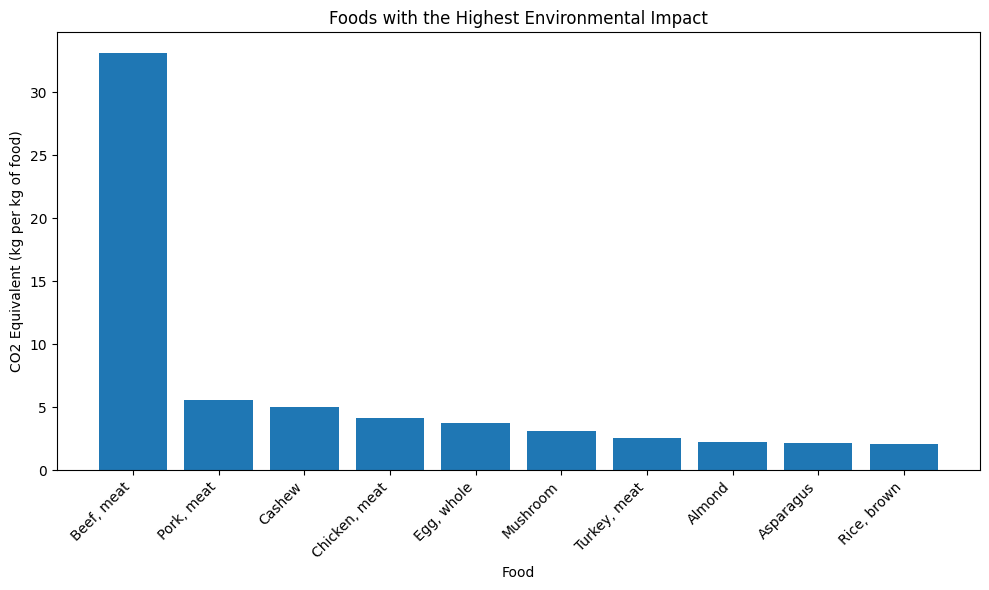

In [95]:
import matplotlib.pyplot as plt

top_environmental = combined_food_data.sort_values(
    "CO2 eq / kg",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))
plt.bar(
    top_environmental["food_name"],
    top_environmental["CO2 eq / kg"]
)

plt.title("Foods with the Highest Environmental Impact")
plt.xlabel("Food")
plt.ylabel("CO2 Equivalent (kg per kg of food)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [96]:
combined_food_data[
    ["food_name", "calories"]
].sort_values(
    "calories",
    ascending=False
).head(10)

,food_name,calories
32,Pecan,691.0
33,Walnut,654.0
30,Almond,579.0
31,Cashew,553.0
10,"Soybean, seed",446.0
36,"Oat, groats/rolled oats",389.0
13,"Chickpea, seed",378.0
37,"Rice, white",365.0
38,"Rice, brown",362.0
34,"Barley, pearled barley",352.0


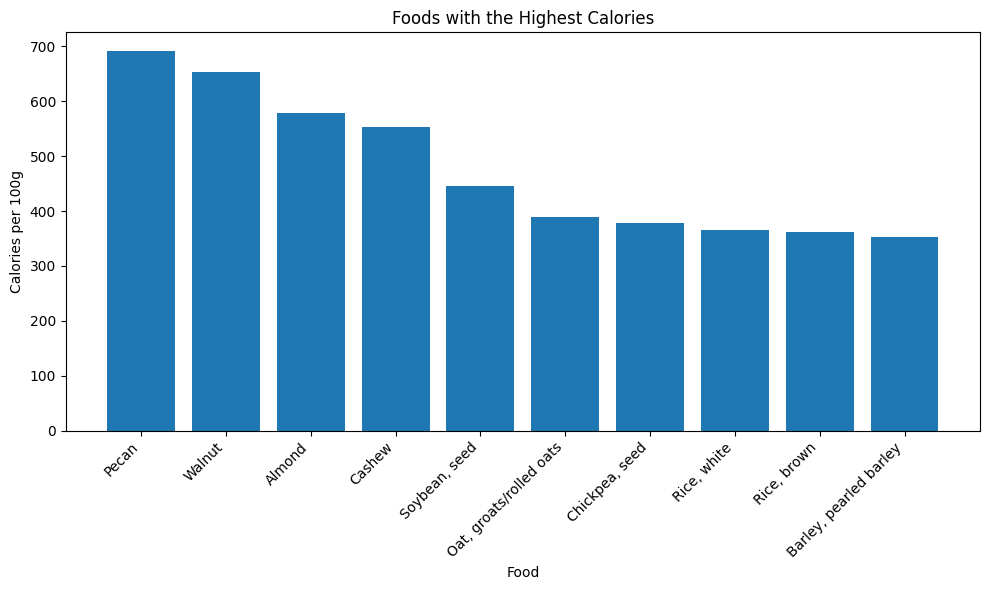

In [97]:
top_calories = combined_food_data.sort_values(
    "calories",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))
plt.bar(
    top_calories["food_name"],
    top_calories["calories"]
)

plt.title("Foods with the Highest Calories")
plt.xlabel("Food")
plt.ylabel("Calories per 100g")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

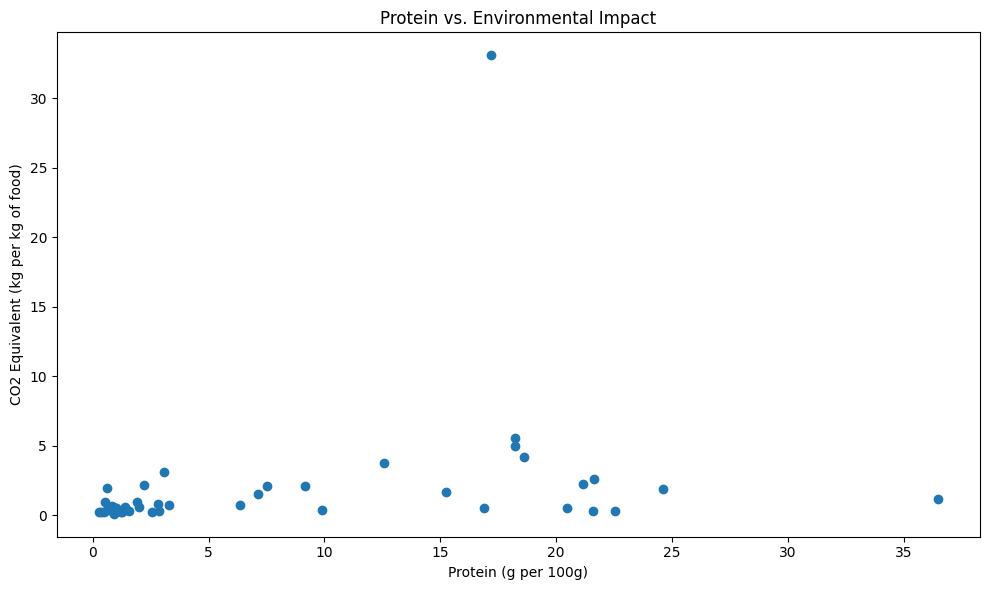

In [98]:
plt.figure(figsize=(10, 6))

plt.scatter(
    combined_food_data["protein_g"],
    combined_food_data["CO2 eq / kg"]
)

plt.title("Protein vs. Environmental Impact")
plt.xlabel("Protein (g per 100g)")
plt.ylabel("CO2 Equivalent (kg per kg of food)")
plt.tight_layout()
plt.show()

In [99]:
correlation = combined_food_data["protein_g"].corr(
    combined_food_data["CO2 eq / kg"]
)

print("Protein and environmental impact correlation:", correlation)

Protein and environmental impact correlation: 0.280622934058474


In [100]:
fat_correlation = combined_food_data["fat_g"].corr(
    combined_food_data["CO2 eq / kg"]
)

print("Fat and environmental impact correlation:", fat_correlation)

Fat and environmental impact correlation: 0.23328224752531815


In [101]:
carbs_correlation = combined_food_data["carbs_g"].corr(
    combined_food_data["CO2 eq / kg"]
)

print("Carbohydrates and environmental impact correlation:", carbs_correlation)

Carbohydrates and environmental impact correlation: -0.1396883159758874


In [102]:
calories_correlation = combined_food_data["calories"].corr(
    combined_food_data["CO2 eq / kg"]
)

print("Calories and environmental impact correlation:", calories_correlation)

Calories and environmental impact correlation: 0.17479527695995084


In [103]:
correlation_matrix = combined_food_data[
    ["protein_g", "fat_g", "carbs_g", "calories", "CO2 eq / kg"]
].corr()

print(correlation_matrix)


             protein_g     fat_g   carbs_g  calories  CO2 eq / kg
protein_g     1.000000  0.444446  0.434694  0.743920     0.280623
fat_g         0.444446  1.000000 -0.028246  0.800495     0.233282
carbs_g       0.434694 -0.028246  1.000000  0.551237    -0.139688
calories      0.743920  0.800495  0.551237  1.000000     0.174795
CO2 eq / kg   0.280623  0.233282 -0.139688  0.174795     1.000000


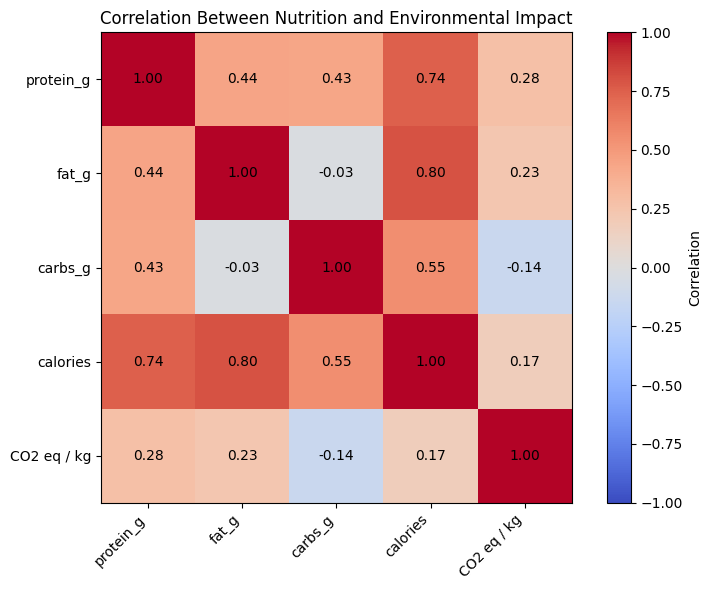

In [105]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Between Nutrition and Environmental Impact")
plt.tight_layout()
plt.show()

### Correlation Analysis

The correlation matrix shows that none of the nutrition variables have a strong relationship with environmental impact. Protein has the strongest relationship with environmental impact at 0.28, followed by fat at 0.23, calories at 0.17 and carbohydrates at -0.14. These are all weak relationships. This suggests that a food's nutritional characteristics alone do not strongly predict its environmental impact. This supports the purpose of the project because meal recommendations will need to consider nutrition and environmental impact separately rather than relying on one factor.

In [106]:
protein_foods = combined_food_data[
    ["food_name", "protein_g", "CO2 eq / kg"]
].sort_values(
    "protein_g",
    ascending=False
).head(10)

protein_foods

,food_name,protein_g,CO2 eq / kg
10,"Soybean, seed",36.49,1.154280
14,"Lentil, seed",24.63,1.880350
12,"Bean, kidney, seed",22.53,0.307787
50,"Turkey, meat",21.64,2.571429
11,"Bean, black, seed",21.60,0.307787
30,Almond,21.15,2.272031
13,"Chickpea, seed",20.47,0.491400
49,"Chicken, meat",18.60,4.187848
31,Cashew,18.22,4.999000
48,"Pork, meat",18.22,5.560044


### Protein and Environmental Impact

Looking at the 10 foods with the highest protein levels shows an important difference between foods. Several plant-based foods, including beans, lentils and chickpeas, provide high amounts of protein while having relatively low environmental impacts. For example, kidney beans and black beans both have more than 21 grams of protein per 100 grams and an environmental impact of about 0.31 kg CO2e per kilogram. Some meat products provide similar amounts of protein but have higher environmental impacts. This shows an important tradeoff that could be useful when developing the meal optimization tool.

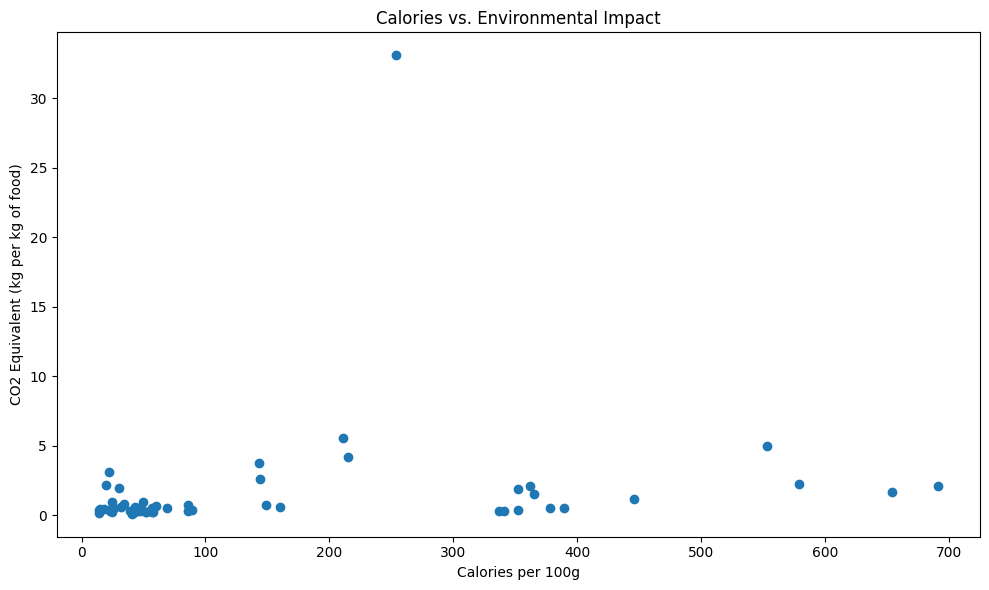

In [107]:
plt.figure(figsize=(10, 6))

plt.scatter(
    combined_food_data["calories"],
    combined_food_data["CO2 eq / kg"]
)

plt.title("Calories vs. Environmental Impact")
plt.xlabel("Calories per 100g")
plt.ylabel("CO2 Equivalent (kg per kg of food)")
plt.tight_layout()
plt.show()

### Calories and Environmental Impact

The scatterplot shows that most foods have relatively low environmental impacts even across different calorie levels. Beef stands out as a food with a much higher environmental impact than the other foods in the dataset. The correlation between calories and environmental impact is 0.17, which is a very weak positive relationship. This suggests that calorie content alone does not strongly predict environmental impact.

In [108]:
fruit_prices = pd.read_csv("../data/raw/ALL_FRUITS.csv")
vegetable_prices = pd.read_csv("../data/raw/ALL_VEGETABLES.csv")

print("Fruit price data:")
print(fruit_prices.shape)
display(fruit_prices.head())

print("\nVegetable price data:")
print(vegetable_prices.shape)
display(vegetable_prices.head())

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/ALL_FRUITS.csv'

In [109]:
import os

print(os.listdir("../data/raw"))

['environmental', 'food.csv', 'food_nutrient.csv', 'fruit-prices-2023.csv', 'nutrient.csv', 'sample_food_data.csv', 'sr_legacy', 'vegetable-prices-2023.csv']


In [110]:
fruit_prices = pd.read_csv("../data/raw/fruit-prices-2023.csv")
vegetable_prices = pd.read_csv("../data/raw/vegetable-prices-2023.csv")

print("Fruit price data:")
print(fruit_prices.shape)
display(fruit_prices.head())

print("\nVegetable price data:")
print(vegetable_prices.shape)
display(vegetable_prices.head())

Fruit price data:
(62, 8)


,Fruit,Form,AverageRetailPrice,AverageRetailPriceUnitOfMeasure,PreparationYieldFactor,SizeOfACupEquivalent,CupEquivalentUnitOfMeasure,AveragePricePerCupEquivalent
0,Apples,Fresh,1.860931,per pound,0.90,0.2425,pounds,0.501435
1,"Apples, applesauce",Canned,1.208099,per pound,1.00,0.5401,pounds,0.652534
2,"Apples, ready to drink",Juice,0.951115,per pint (16 fluid ounces ready to drink),1.00,0.5000,pints,0.475558
3,"Apples, frozen concentrate",Juice,2.668334,per pint (16 fluid ounces concentrate),4.00,0.5000,pints,0.333542
4,Apricots,Fresh,3.803732,per pound,0.93,0.3638,pounds,1.487802



Vegetable price data:
(93, 8)


,Vegetable,Form,AverageRetailPrice,AverageRetailPriceUnitOfMeasure,PreparationYieldFactor,SizeOfACupEquivalent,CupEquivalentUnitOfMeasure,AveragePricePerCupEquivalent
0,Acorn squash,Fresh,1.241439,per pound,0.4586,0.4519,pounds,1.223533
1,Artichoke,Fresh,2.506856,per pound,0.3750,0.3858,pounds,2.080461
2,Artichoke,Canned,3.505101,per pound,0.6500,0.3858,pounds,2.579113
3,Asparagus,Fresh,3.212453,per pound,0.4938,0.3968,pounds,2.581436
4,Asparagus,Canned,3.676296,per pound,0.6500,0.3968,pounds,2.244419


In [111]:
print("FRUIT PRICES")
print(fruit_prices[["Fruit", "Form"]].to_string(index=False))

print("\nVEGETABLE PRICES")
print(vegetable_prices[["Vegetable", "Form"]].to_string(index=False))

FRUIT PRICES
                            Fruit   Form
                           Apples  Fresh
               Apples, applesauce Canned
           Apples, ready to drink  Juice
       Apples, frozen concentrate  Juice
                         Apricots  Fresh
               Apricots, in juice Canned
      Apricots, in syrup or water Canned
                         Apricots  Dried
                          Bananas  Fresh
                   Berries, mixed Frozen
                     Blackberries  Fresh
                     Blackberries Frozen
                      Blueberries  Fresh
                      Blueberries Frozen
                       Cantaloupe  Fresh
                         Cherries  Fresh
      Cherries, in syrup or water Canned
                      Clementines  Fresh
                      Cranberries  Dried
                            Dates  Dried
                             Figs  Dried
         Fruit cocktail, in juice Canned
Fruit cocktail, in syrup or water Canned
   

In [112]:
foods_to_check = [
    "Apples",
    "Apricots",
    "Bananas",
    "Blackberries",
    "Blueberries",
    "Grapes",
    "Mangoes",
    "Oranges",
    "Papaya",
    "Peaches",
    "Pears",
    "Pineapple",
    "Raspberries",
    "Strawberries",
    "Watermelon",
    "Asparagus",
    "Avocados",
    "Black beans",
    "Broccoli heads",
    "Cabbage, green",
    "Carrots, raw whole",
    "Cauliflower heads",
    "Celery, trimmed bunches",
    "Corn",
    "Cucumbers with peel",
    "Green peppers",
    "Lettuce, iceberg",
    "Mushrooms, whole",
    "Onions",
    "Potatoes",
    "Spinach, eaten raw",
    "Sweet potatoes",
    "Tomatoes, large round",
    "Kidney beans",
    "Lentils"
]

fruit_matches = fruit_prices[
    fruit_prices["Fruit"].isin(foods_to_check)
]

vegetable_matches = vegetable_prices[
    vegetable_prices["Vegetable"].isin(foods_to_check)
]

print("FRUIT MATCHES")
display(fruit_matches[[
    "Fruit",
    "Form",
    "AverageRetailPrice",
    "AverageRetailPriceUnitOfMeasure"
]])

print("\nVEGETABLE MATCHES")
display(vegetable_matches[[
    "Vegetable",
    "Form",
    "AverageRetailPrice",
    "AverageRetailPriceUnitOfMeasure"
]])

FRUIT MATCHES


,Fruit,Form,AverageRetailPrice,AverageRetailPriceUnitOfMeasure
0,Apples,Fresh,1.860931,per pound
4,Apricots,Fresh,3.803732,per pound
7,Apricots,Dried,8.634284,per pound
8,Bananas,Fresh,0.609595,per pound
10,Blackberries,Fresh,6.834469,per pound
11,Blackberries,Frozen,4.705827,per pound
12,Blueberries,Fresh,5.132473,per pound
13,Blueberries,Frozen,4.199261,per pound
25,Grapes,Fresh,2.248437,per pound
31,Mangoes,Fresh,1.458676,per pound



VEGETABLE MATCHES


,Vegetable,Form,AverageRetailPrice,AverageRetailPriceUnitOfMeasure
3,Asparagus,Fresh,3.212453,per pound
4,Asparagus,Canned,3.676296,per pound
5,Asparagus,Frozen,6.780905,per pound
6,Avocados,Fresh,2.262403,per pound
8,Black beans,Canned,1.306313,per pound
9,Black beans,Dried,1.658510,per pound
13,Broccoli heads,Fresh,3.023555,per pound
18,"Cabbage, green",Fresh,0.826627,per pound
22,"Carrots, raw whole",Fresh,1.005541,per pound
27,Cauliflower heads,Fresh,2.124437,per pound


In [113]:
fresh_fruit_prices = fruit_prices[
    fruit_prices["Form"] == "Fresh"
].copy()

fresh_vegetable_prices = vegetable_prices[
    vegetable_prices["Form"] == "Fresh"
].copy()

print("Fresh fruit prices:", fresh_fruit_prices.shape)
print("Fresh vegetable prices:", fresh_vegetable_prices.shape)

Fresh fruit prices: (24, 8)
Fresh vegetable prices: (42, 8)


In [114]:
display(fresh_fruit_prices.head())
display(fresh_vegetable_prices.head())

,Fruit,Form,AverageRetailPrice,AverageRetailPriceUnitOfMeasure,PreparationYieldFactor,SizeOfACupEquivalent,CupEquivalentUnitOfMeasure,AveragePricePerCupEquivalent
0,Apples,Fresh,1.860931,per pound,0.90,0.2425,pounds,0.501435
4,Apricots,Fresh,3.803732,per pound,0.93,0.3638,pounds,1.487802
8,Bananas,Fresh,0.609595,per pound,0.64,0.3307,pounds,0.314983
10,Blackberries,Fresh,6.834469,per pound,0.96,0.3197,pounds,2.275809
12,Blueberries,Fresh,5.132473,per pound,0.95,0.3197,pounds,1.727052


,Vegetable,Form,AverageRetailPrice,AverageRetailPriceUnitOfMeasure,PreparationYieldFactor,SizeOfACupEquivalent,CupEquivalentUnitOfMeasure,AveragePricePerCupEquivalent
0,Acorn squash,Fresh,1.241439,per pound,0.4586,0.4519,pounds,1.223533
1,Artichoke,Fresh,2.506856,per pound,0.3750,0.3858,pounds,2.080461
3,Asparagus,Fresh,3.212453,per pound,0.4938,0.3968,pounds,2.581436
6,Avocados,Fresh,2.262403,per pound,0.7408,0.3197,pounds,0.976334
12,Broccoli florets,Fresh,3.083131,per pound,1.0000,0.3417,pounds,1.053557


In [115]:
print(os.listdir("../data/raw"))

['environmental', 'food.csv', 'food_nutrient.csv', 'fruit-prices-2023.csv', 'nutrient.csv', 'sample_food_data.csv', 'sr_legacy', 'vegetable-prices-2023.csv']


In [116]:
print(os.listdir("../data/raw"))

['cuts.csv', 'environmental', 'food.csv', 'food_nutrient.csv', 'fruit-prices-2023.csv', 'nutrient.csv', 'sample_food_data.csv', 'sr_legacy', 'vegetable-prices-2023.csv']


In [117]:
meat_prices = pd.read_csv("../data/raw/cuts.csv")

print("Meat price data:")
print(meat_prices.shape)
display(meat_prices.head())

Meat price data:
(800, 7)


,Year,Month,Month_Number,Data_Item,Value,Units,Source
0,2024,August,8,Ground chuck retail price,5.638,Dollars per pound,BLS
1,2024,September,9,Ground chuck retail price,5.576,Dollars per pound,BLS
2,2024,October,10,Ground chuck retail price,5.586,Dollars per pound,BLS
3,2024,November,11,Ground chuck retail price,5.605,Dollars per pound,BLS
4,2024,December,12,Ground chuck retail price,5.576,Dollars per pound,BLS


In [118]:
print(meat_prices["Data_Item"].unique())

<StringArray>
[                            'Ground chuck retail price',
                              'Ground beef retail price',
            'Lean & extra lean ground beef retail price',
                 'All uncooked ground beef retail price',
       'Chuck roast, USDA Choice, boneless retail price',
        'Round roast, USDA Choice boneless retail price',
                 'Round steak, USDA Choice retail price',
                 'All uncooked beef roasts retail price',
      'Sirloin steak, USDA Choice boneless retail price',
                  'Beef for stew, boneless retail price',
                 'All uncooked beef steaks retail price',
         'All uncooked other beef not veal retail price',
                            'Bacon, sliced retail price',
          'Pork chops, center cut, bone in retail price',
                    'Pork chops, boneless, retail price',
                           'All pork chops retail price',
                 'Ham, boneless not canned retail price',


In [119]:
print(meat_prices["Year"].unique())

[2024 2025 2026]


In [120]:
selected_meat = meat_prices[
    (
        meat_prices["Data_Item"].isin([
            "All uncooked beef roasts retail price",
            "All pork chops retail price",
            "Chicken, fresh whole retail price",
            "Eggs, Grade A large retail price"
        ])
    )
    & (meat_prices["Year"] == 2024)
]

display(
    selected_meat[
        ["Year", "Month", "Data_Item", "Value", "Units"]
    ]
)

,Year,Month,Data_Item,Value,Units
175,2024,August,All uncooked beef roasts retail price,7.630,Dollars per pound
176,2024,September,All uncooked beef roasts retail price,7.582,Dollars per pound
177,2024,October,All uncooked beef roasts retail price,7.368,Dollars per pound
178,2024,November,All uncooked beef roasts retail price,7.598,Dollars per pound
179,2024,December,All uncooked beef roasts retail price,7.719,Dollars per pound
375,2024,August,All pork chops retail price,4.403,Dollars per pound
376,2024,September,All pork chops retail price,4.328,Dollars per pound
377,2024,October,All pork chops retail price,4.273,Dollars per pound
378,2024,November,All pork chops retail price,4.430,Dollars per pound
379,2024,December,All pork chops retail price,4.308,Dollars per pound


In [121]:
meat_averages = (
    selected_meat
    .groupby("Data_Item")["Value"]
    .mean()
    .reset_index()
)

meat_averages.columns = ["Data_Item", "Average_Price_Per_Pound"]

meat_averages

,Data_Item,Average_Price_Per_Pound
0,All pork chops retail price,4.3484
1,All uncooked beef roasts retail price,7.5794
2,"Chicken, fresh whole retail price",2.0182
3,"Eggs, Grade A large retail price",3.6380


In [122]:
fruit_price_match = fresh_fruit_prices[
    fresh_fruit_prices["Fruit"].isin([
        "Apples",
        "Apricots",
        "Bananas",
        "Blackberries",
        "Blueberries",
        "Grapes",
        "Mangoes",
        "Oranges",
        "Papaya",
        "Peaches",
        "Pears",
        "Pineapple",
        "Raspberries",
        "Strawberries",
        "Watermelon"
    ])
][["Fruit", "AverageRetailPrice"]].copy()

vegetable_price_match = fresh_vegetable_prices[
    fresh_vegetable_prices["Vegetable"].isin([
        "Asparagus",
        "Avocados",
        "Black beans",
        "Broccoli heads",
        "Cabbage, green",
        "Carrots, raw whole",
        "Cauliflower heads",
        "Celery, trimmed bunches",
        "Corn",
        "Cucumbers with peel",
        "Green peppers",
        "Kidney beans",
        "Lentils",
        "Lettuce, iceberg",
        "Mushrooms, whole",
        "Onions",
        "Potatoes",
        "Spinach, eaten raw",
        "Sweet potatoes",
        "Tomatoes, large round"
    ])
][["Vegetable", "AverageRetailPrice"]].copy()

print("Fruit price matches:")
display(fruit_price_match)

print("\nVegetable price matches:")
display(vegetable_price_match)

Fruit price matches:


,Fruit,AverageRetailPrice
0,Apples,1.860931
4,Apricots,3.803732
8,Bananas,0.609595
10,Blackberries,6.834469
12,Blueberries,5.132473
25,Grapes,2.248437
31,Mangoes,1.458676
34,Oranges,1.439704
37,Papaya,1.305513
39,Peaches,2.457099



Vegetable price matches:


,Vegetable,AverageRetailPrice
3,Asparagus,3.212453
6,Avocados,2.262403
13,Broccoli heads,3.023555
18,"Cabbage, green",0.826627
22,"Carrots, raw whole",1.005541
27,Cauliflower heads,2.124437
29,"Celery, trimmed bunches",1.327845
34,Corn,2.102764
37,Cucumbers with peel,1.092848
46,Green peppers,1.503335


In [123]:
display(
    vegetable_prices[
        vegetable_prices["Vegetable"].isin([
            "Black beans",
            "Kidney beans",
            "Lentils"
        ])
    ][[
        "Vegetable",
        "Form",
        "AverageRetailPrice",
        "AverageRetailPriceUnitOfMeasure",
        "AveragePricePerCupEquivalent"
    ]]
)

,Vegetable,Form,AverageRetailPrice,AverageRetailPriceUnitOfMeasure,AveragePricePerCupEquivalent
8,Black beans,Canned,1.306313,per pound,0.775365
9,Black beans,Dried,1.658510,per pound,0.259142
49,Kidney beans,Canned,1.199920,per pound,0.712215
50,Kidney beans,Dried,1.996333,per pound,0.311927
51,Lentils,Dried,1.957697,per pound,0.305890


In [124]:
display(
    vegetable_prices[
        vegetable_prices["Vegetable"].isin([
            "Garlic",
            "Eggplant",
            "Green peppers"
        ])
    ][[
        "Vegetable",
        "Form",
        "AverageRetailPrice",
        "AverageRetailPriceUnitOfMeasure",
        "AveragePricePerCupEquivalent"
    ]]
)

,Vegetable,Form,AverageRetailPrice,AverageRetailPriceUnitOfMeasure,AveragePricePerCupEquivalent
46,Green peppers,Fresh,1.503335,per pound,0.485017


In [125]:
display(
    nutrition_for_project[
        nutrition_for_project["food_name"].isin([
            "Almond",
            "Cashew",
            "Pecan",
            "Walnut",
            "Barley, pearled barley",
            "Oat, groats/rolled oats",
            "Rice, white",
            "Rice, brown",
            "Soybean, seed",
            "Chickpea, seed"
        ])
    ][[
        "food_name",
        "description"
    ]]
)

,food_name,description
1365,"Rice, white","Rice, white, long-grain, regular, raw, enriched"
2193,"Oat, groats/rolled oats",Oats (Includes foods for USDA's Food Distribut...
2194,"Rice, brown","Rice, brown, medium-grain, raw (Includes foods..."
2650,Cashew,"Nuts, cashew nuts, raw"
2670,Pecan,"Nuts, pecans"
2675,Walnut,"Nuts, walnuts, english"
2772,"Barley, pearled barley","Barley, pearled, raw"
3055,Almond,"Nuts, almonds"
6244,"Chickpea, seed","Chickpeas (garbanzo beans, bengal gram), matur..."
6758,"Soybean, seed","Soybeans, mature seeds, raw"


In [126]:
meat_prices[
    meat_prices["Data_Item"].str.contains(
        "turkey",
        case=False,
        na=False
    )
][[
    "Year",
    "Month",
    "Data_Item",
    "Value",
    "Units"
]]

,Year,Month,Data_Item,Value,Units


In [128]:
purchase_prices = pd.read_csv(
    "../data/raw/pp_national_average_prices_csv.csv",
    encoding="cp1252"
)

print("Shape:", purchase_prices.shape)
print("\nColumns:")
print(purchase_prices.columns.tolist())

display(purchase_prices.head())

Shape: (15012, 8)

Columns:
['year', 'food_code', 'mod_code', 'food_description', 'method', 'method_description', 'nhanes', 'price_100gm']


,year,food_code,mod_code,food_description,method,method_description,nhanes,price_100gm
0,2011/2012,11100000.0,0.0,"Milk, NFS",4,FNDDS recipe with modified SR codes,NaN,0.091897
1,2011/2012,11111000.0,0.0,"Milk, cow's, fluid, whole (Includes 3.5% or 3....",1,Links to FNDDS,NaN,0.094505
2,2011/2012,11112110.0,0.0,"Milk, cow's, fluid, 2% fat (Includes Hi-Protei...",1,Links to FNDDS,NaN,0.088018
3,2011/2012,11112210.0,0.0,"Milk, cow's, fluid, 1% fat (Includes Lucerne P...",1,Links to FNDDS,NaN,0.089206
4,2011/2012,11113000.0,0.0,"Milk, cow's, fluid, skim or nonfat, 0.5% or le...",1,Links to FNDDS,NaN,0.088424


In [129]:
missing_price_foods = [
    "Garlic",
    "Eggplant",
    "Turkey",
    "Almond",
    "Cashew",
    "Pecan",
    "Walnut",
    "Barley",
    "Oats",
    "Rice",
    "Chickpea",
    "Soybean"
]

matches = purchase_prices[
    purchase_prices["food_description"].str.contains(
        "|".join(missing_price_foods),
        case=False,
        na=False
    )
]

display(
    matches[
        ["year", "food_description", "method_description", "price_100gm"]
    ].head(50)
)

,year,food_description,method_description,price_100gm
23,2011/2012,"Milk, almond, ready-to-drink (Includes Blue Di...",Links to FNDDS,0.160109
24,2011/2012,"Milk, almond, ready-to-drink, chocolate (Inclu...",Links to FNDDS,0.177798
36,2011/2012,"Yogurt, chocolate, nonfat milk (Includes Snack...",Links to FNDDS,0.184971
48,2011/2012,"Yogurt, frozen, flavors other than chocolate, ...",Links to FNDDS,0.244015
197,2011/2012,"Ice cream, no sugar added, flavors other than ...",Links to FNDDS,0.273928
198,2011/2012,"Ice cream, no sugar added, chocolate (Includes...",Links to FNDDS,0.261174
228,2011/2012,"Ice cream sandwich, made with light ice cream,...",Links to altEC,0.630582
236,2011/2012,"Fat free ice cream, no sugar added, flavors ot...",Links to FNDDS,0.281000
252,2011/2012,"Pudding, rice",Links to FNDDS,0.456922
329,2011/2012,"Cheese spread, Swiss cheese base (Includes Swi...",Links to altEC,1.680504


In [130]:
purchase_prices[
    purchase_prices["food_description"].isin([
        "Turkey, NFS",
        "Turkey, ground"
    ])
][[
    "year",
    "food_description",
    "price_100gm"
]]

,year,food_description,price_100gm
530,2011/2012,"Turkey, NFS",1.070869
545,2011/2012,"Turkey, ground",1.279364
4112,2013/2014,"Turkey, NFS",0.935295
4125,2013/2014,"Turkey, ground",1.474631
11309,2017/2018,"Turkey, NFS",0.844469
11330,2017/2018,"Turkey, ground",1.424761


In [131]:
price_search = purchase_prices[
    purchase_prices["food_description"].str.contains(
        "almond|cashew|pecan|walnut|barley|oat|rice|chickpea|soybean|garlic|eggplant",
        case=False,
        na=False
    )
]

display(
    price_search[
        [
            "year",
            "food_description",
            "price_100gm"
        ]
    ].tail(100)
)

,year,food_description,price_100gm
13691,2017/2018,"Rice, brown, with corn, NS as to fat (Includes...",0.255515
13692,2017/2018,"Rice, brown, with peas, NS as to fat (Includes...",0.253527
13693,2017/2018,"Rice, brown, with peas, fat added (Includes ri...",0.253527
13694,2017/2018,"Rice, brown, with carrots, NS as to fat (Inclu...",0.245161
13695,2017/2018,"Rice, brown, with peas and carrots, no added f...",0.249690
...,...,...,...
14837,2017/2018,"Tea, hot, leaf, green, decaffeinated (Includes...",0.117409
14931,2017/2018,"Horchata beverage, made with water (Includes H...",0.113076
14932,2017/2018,Oatmeal beverage with water (Includes Frescave...,0.331417
14940,2017/2018,"Beer, higher alcohol (Includes barley wine)",0.346775


In [132]:
keywords = [
    "Almond",
    "Cashew",
    "Pecan",
    "Walnut",
    "Barley, pearled",
    "Oats",
    "Rice, white",
    "Rice, brown",
    "Chickpeas",
    "Soybeans",
    "Garlic",
    "Eggplant"
]

for keyword in keywords:
    print("\n---", keyword, "---")
    
    results = purchase_prices[
        purchase_prices["food_description"].str.contains(
            keyword,
            case=False,
            na=False
        )
        & (purchase_prices["year"] == "2017/2018")
    ][["food_description", "price_100gm"]]
    
    display(results.head(10))


--- Almond ---


,food_description,price_100gm
10605,"Almond milk, sweetened (Includes vanilla flavo...",0.169743
10606,"Almond milk, sweetened, chocolate (Includes NS...",0.170165
10607,"Almond milk, unsweetened (Includes unsweetened...",0.156240
10608,"Almond milk, unsweetened, chocolate (Includes ...",0.156240
10672,"Hot chocolate / Cocoa, ready to drink, made wi...",0.136549
10678,"Chocolate milk, made from dry mix with non-dai...",0.221726
10684,"Chocolate milk, made from reduced sugar mix wi...",0.218636
10690,"Chocolate milk, made from dry mix with non-dai...",0.221726
10696,"Chocolate milk, made from no sugar added dry m...",0.218636
10702,"Chocolate milk, made from syrup with non-dairy...",0.195724



--- Cashew ---


,food_description,price_100gm
10605,"Almond milk, sweetened (Includes vanilla flavo...",0.169743
10606,"Almond milk, sweetened, chocolate (Includes NS...",0.170165
10607,"Almond milk, unsweetened (Includes unsweetened...",0.156240
11887,Kung pao chicken (Includes cashew chicken),1.278684
12404,"Cashews, unroasted (Includes raw)",2.508193
12405,"Cashews, salted (Includes NS as to salt; plain...",1.882790
12406,"Cashews, lightly salted (Includes plain; roast...",2.045382
12407,"Cashews, unsalted (Includes plain; roasted; no...",1.872872
12408,"Cashews, honey roasted",2.243683
12444,Cashew butter,2.069454



--- Pecan ---


...

,food_description,price_100gm
12320,"Soybeans, cooked (Includes with or without fat...",0.929607
12368,"Vermicelli, made from soybeans (Includes bean ...",0.243763



--- Garlic ---


,food_description,price_100gm
11883,Chicken or turkey and vegetables excluding car...,0.606144
12513,"Garlic bread, NFS",0.712875
12514,"Garlic bread, from fast food / restaurant (Inc...",0.712875
12515,"Garlic bread, from frozen (Includes homemade; ...",0.712875
12516,"Garlic bread, with parmesan cheese, from fast ...",0.748909
12517,"Garlic bread, with parmesan cheese, from froze...",0.712875
12518,"Garlic bread, with melted cheese, from fast fo...",0.748909
12519,"Garlic bread, with melted cheese, from frozen ...",0.839910
12537,"Roll, garlic",2.037825
12560,"Breadsticks, soft, from fast food / restaurant...",1.180513



--- Eggplant ---


,food_description,price_100gm
14259,"Eggplant, raw",0.486766
14374,"Eggplant, cooked, no added fat (Includes cooki...",0.522645
14375,"Eggplant, cooked, fat added (Includes NS as to...",0.522891
14449,Ratatouille (Includes vegetable mixture of egg...,0.520534
14465,Fried eggplant (Includes battered or breaded),0.967009
14466,Eggplant dip (Includes Baba Ghanoush),1.144089
14467,"Eggplant parmesan casserole, regular",1.015040
14468,Eggplant with cheese and tomato sauce (Include...,0.617896
14546,Eggplant and meat casserole (Includes Moussaka...,0.632137


In [133]:
for keyword in ["almonds", "oats", "barley", "rice, white"]:
    print("\n---", keyword, "---")
    
    results = purchase_prices[
        purchase_prices["food_description"].str.contains(
            keyword,
            case=False,
            na=False
        )
        & (purchase_prices["year"] == "2017/2018")
    ][["food_description", "price_100gm"]]
    
    display(results.head(15))


--- almonds ---


,food_description,price_100gm
12396,"Almonds, NFS",1.867590
12397,"Almonds, unroasted (Includes raw)",1.929940
12398,"Almonds, salted (Includes NS as to salt; plain...",1.835493
12399,"Almonds, lightly salted (Includes plain; roast...",1.720467
12400,"Almonds, unsalted (Includes plain; roasted; no...",1.843931
12401,"Almonds, flavored (Includes all flavors other ...",1.959495
12402,"Almonds, honey roasted",2.406457
13244,Cereal (Post Honey Bunches of Oats with Almonds),0.599773
13273,Cereal (General Mills Oatmeal Crisp with Almonds),0.817154
14687,"Almonds, chocolate covered",1.814804



--- oats ---


,food_description,price_100gm
10638,"Yogurt, Greek, with oats (Includes all types; ...",0.719278
12881,Cereal or granola bar (Quaker Chewy Granola Ba...,0.946308
12886,"Cereal or Granola bar, NFS (Includes with choc...",1.107601
12887,"Cereal or granola bar, lowfat, NFS (Includes a...",1.250880
12889,"Cereal or granola bar, peanuts , oats, sugar, ...",1.250880
12893,"Cereal or granola bar, coated with non-chocola...",0.930301
13105,"Buckwheat groats, NS as to fat (Includes kasha...",0.356136
13106,"Buckwheat groats, no added fat (Includes kasha...",0.356136
13107,"Buckwheat groats, fat added (Includes kasha; a...",0.356756
13242,Cereal (Post Honey Bunches of Oats Honey Roast...,0.623858



--- barley ---


,food_description,price_100gm
13103,"Barley, NS as to fat (Includes all liquids)",0.108533
13104,"Barley, no added fat (Includes all liquids)",0.108533
13755,"Barley soup, home recipe, canned, or ready-to-...",0.354469
14940,"Beer, higher alcohol (Includes barley wine)",0.346775



--- rice, white ---


,food_description,price_100gm
13160,"Rice, white, cooked, NS as to fat (Includes ba...",0.744832
13161,"Rice, white, cooked, made with oil (Includes b...",0.093141
13162,"Rice, white, cooked, made with butter (Include...",0.105983
13163,"Rice, white, cooked, made with margarine (Incl...",0.091753
13164,"Rice, white, cooked, fat added, NS as to fat t...",0.095294
13165,"Rice, white, cooked, no added fat (Includes ba...",0.089641
13177,"Rice, white, cooked, glutinous (Includes stick...",0.141963
13181,"Rice, white and wild, cooked, no added fat (In...",0.429349
13182,"Rice, white and wild, cooked, fat added (Inclu...",0.103095
13183,"Rice, white and wild, cooked, NS as to fat (In...",0.103095


In [134]:
purchase_price_matches = {
    "Almond": ("Almonds, unroasted (Includes raw)", 1.929940),
    "Oat, groats/rolled oats": ("Oats, raw", 0.433131),
    "Barley, pearled barley": ("Barley, NS as to fat", 0.108533),
    "Cashew": ("Cashews, unroasted (Includes raw)", 2.508193),
    "Pecan": ("Pecans, unroasted (Includes raw)", 2.465712),
    "Walnut": ("Walnuts, excluding honey roasted (Includes NFS)", 1.741183),
    "Chickpea, seed": ("Chickpeas, NFS (Includes garbanzos; ceci)", 0.321080),
    "Eggplant": ("Eggplant, raw", 0.486766),
    "Turkey, meat": ("Turkey, NFS", 0.844469)
}

price_lookup = pd.DataFrame(
    [
        [food, description, price]
        for food, (description, price) in purchase_price_matches.items()
    ],
    columns=["food_name", "price_source", "price_per_100g"]
)

price_lookup

,food_name,price_source,price_per_100g
0,Almond,"Almonds, unroasted (Includes raw)",1.929940
1,"Oat, groats/rolled oats","Oats, raw",0.433131
2,"Barley, pearled barley","Barley, NS as to fat",0.108533
3,Cashew,"Cashews, unroasted (Includes raw)",2.508193
4,Pecan,"Pecans, unroasted (Includes raw)",2.465712
5,Walnut,"Walnuts, excluding honey roasted (Includes NFS)",1.741183
6,"Chickpea, seed","Chickpeas, NFS (Includes garbanzos; ceci)",0.321080
7,Eggplant,"Eggplant, raw",0.486766
8,"Turkey, meat","Turkey, NFS",0.844469


In [135]:
# Convert prices from dollars per pound to dollars per 100g
pound_to_100g = 100 / 453.59237

fresh_fruit_prices["price_per_100g"] = (
    fresh_fruit_prices["AverageRetailPrice"] * pound_to_100g
)

fresh_vegetable_prices["price_per_100g"] = (
    fresh_vegetable_prices["AverageRetailPrice"] * pound_to_100g
)

print("Fruit prices:")
display(
    fresh_fruit_prices[
        ["Fruit", "AverageRetailPrice", "price_per_100g"]
    ]
)

print("Vegetable prices:")
display(
    fresh_vegetable_prices[
        ["Vegetable", "AverageRetailPrice", "price_per_100g"]
    ]
)

Fruit prices:


,Fruit,AverageRetailPrice,price_per_100g
0,Apples,1.860931,0.410265
4,Apricots,3.803732,0.838579
8,Bananas,0.609595,0.134393
10,Blackberries,6.834469,1.506742
12,Blueberries,5.132473,1.131517
14,Cantaloupe,0.791924,0.174589
15,Cherries,3.659903,0.806871
17,Clementines,1.585573,0.349559
23,Grapefruit,1.395776,0.307716
25,Grapes,2.248437,0.495695


Vegetable prices:


,Vegetable,AverageRetailPrice,price_per_100g
0,Acorn squash,1.241439,0.273690
1,Artichoke,2.506856,0.552667
3,Asparagus,3.212453,0.708225
6,Avocados,2.262403,0.498774
12,Broccoli florets,3.083131,0.679714
13,Broccoli heads,3.023555,0.666580
15,Brussels sprouts,3.039542,0.670104
17,Butternut squash,1.270953,0.280197
18,"Cabbage, green",0.826627,0.182240
19,"Cabbage, red",1.260672,0.277931


In [136]:
# Match fruit prices to the food names used in our project
fruit_price_lookup = {
    "Apple, fruit with peel": 0.410265,
    "Apricot": 0.838579,
    "Banana": 0.134393,
    "Blackberry": 1.506742,
    "Blueberry": 1.131517,
    "Grape": 0.495695,
    "Mango": 0.321583,
    "Orange": 0.317400,
    "Papaya": 0.287816,
    "Peach": 0.541698,
    "Pear": 0.422569,
    "Pineapple": 0.147363,
    "Raspberry": 1.756369,
    "Strawberry": 0.678745,
    "Watermelon": 0.089469
}

# Match vegetable prices to the food names used in our project
vegetable_price_lookup = {
    "Asparagus": 0.708225,
    "Avocado": 0.498774,
    "Broccoli": 0.666580,
    "Cabbage": 0.182240,
    "Carrot": 0.221684,
    "Cauliflower": 0.468358,
    "Celery": 0.292740,
    "Corn, sweet": 0.463580,
    "Cucumber": 0.240932,
    "Lettuce, head": 0.325928,
    "Mushroom": 0.915915,
    "Onion, bulb": 0.234176,
    "Potato, tuber, w/peel": 0.203166,
    "Spinach": 0.992173,
    "Sweet potato": 0.256756,
    "Tomato": 0.472321,
    "Pepper, bell": 0.331429
}

print("Fruit price matches:", len(fruit_price_lookup))
print("Vegetable price matches:", len(vegetable_price_lookup))

Fruit price matches: 15
Vegetable price matches: 17


In [137]:
# Prices already identified for beans and lentils
other_food_prices = {
    "Bean, black, seed": 0.365777,
    "Bean, kidney, seed": 0.441042,
    "Lentil, seed": 0.431389,
    
    # Meat prices from the USDA/BLS 2024 data
    "Beef, meat": 7.5794,
    "Pork, meat": 4.3484,
    "Chicken, meat": 2.0182,
    
    # Purchase to Plate 2017/2018 prices
    "Turkey, meat": 0.844469,
    "Egg, whole": None
}

other_food_prices

{'Bean, black, seed': 0.365777,
 'Bean, kidney, seed': 0.441042,
 'Lentil, seed': 0.431389,
 'Beef, meat': 7.5794,
 'Pork, meat': 4.3484,
 'Chicken, meat': 2.0182,
 'Turkey, meat': 0.844469,
 'Egg, whole': None}

In [138]:
print("Your current meat averages:")
display(meat_averages)

print("\nYour purchase-to-plate prices:")
display(price_lookup)

Your current meat averages:


,Data_Item,Average_Price_Per_Pound
0,All pork chops retail price,4.3484
1,All uncooked beef roasts retail price,7.5794
2,"Chicken, fresh whole retail price",2.0182
3,"Eggs, Grade A large retail price",3.6380



Your purchase-to-plate prices:


,food_name,price_source,price_per_100g
0,Almond,"Almonds, unroasted (Includes raw)",1.929940
1,"Oat, groats/rolled oats","Oats, raw",0.433131
2,"Barley, pearled barley","Barley, NS as to fat",0.108533
3,Cashew,"Cashews, unroasted (Includes raw)",2.508193
4,Pecan,"Pecans, unroasted (Includes raw)",2.465712
5,Walnut,"Walnuts, excluding honey roasted (Includes NFS)",1.741183
6,"Chickpea, seed","Chickpeas, NFS (Includes garbanzos; ceci)",0.321080
7,Eggplant,"Eggplant, raw",0.486766
8,"Turkey, meat","Turkey, NFS",0.844469


In [139]:
# Convert meat prices from dollars per pound to dollars per 100g
meat_price_lookup = {
    "Beef, meat": 7.5794 * (100 / 453.59237),
    "Pork, meat": 4.3484 * (100 / 453.59237),
    "Chicken, meat": 2.0182 * (100 / 453.59237),
    "Turkey, meat": 0.844469,
    
    # Egg price is left out for now because it is reported per dozen
}

# Combine all of our price sources
all_price_lookup = {}

all_price_lookup.update(fruit_price_lookup)
all_price_lookup.update(vegetable_price_lookup)
all_price_lookup.update(other_food_prices)
all_price_lookup.update(meat_price_lookup)

# Add the Purchase to Plate prices
for food, price in purchase_price_matches.items():
    all_price_lookup[food] = price

# Create a DataFrame
price_data = pd.DataFrame(
    list(all_price_lookup.items()),
    columns=["food_name", "price_per_100g"]
)

print("Number of price records:", len(price_data))
display(price_data)

Number of price records: 48


,food_name,price_per_100g
0,"Apple, fruit with peel",0.410265
1,Apricot,0.838579
2,Banana,0.134393
3,Blackberry,1.506742
4,Blueberry,1.131517
5,Grape,0.495695
6,Mango,0.321583
7,Orange,0.3174
8,Papaya,0.287816
9,Peach,0.541698


In [140]:
# Compare our 52 project foods with the foods that have prices
project_foods = set(combined_food_data["food_name"])

priced_foods = set(price_data["food_name"])

missing_prices = sorted(project_foods - priced_foods)

print("Project foods:", len(project_foods))
print("Foods with prices:", len(priced_foods))
print("Foods missing prices:", len(missing_prices))
print("\nMissing prices:")
print(missing_prices)

Project foods: 52
Foods with prices: 48
Foods missing prices: 4

Missing prices:
['Garlic, bulb', 'Rice, brown', 'Rice, white', 'Soybean, seed']


In [141]:
for keyword in ["garlic", "rice", "soybean"]:
    print("\n---", keyword, "---")
    
    results = purchase_prices[
        purchase_prices["food_description"].str.contains(
            keyword,
            case=False,
            na=False
        )
        & (purchase_prices["year"] == "2017/2018")
    ][["food_description", "price_100gm"]]
    
    display(results.head(30))


--- garlic ---


,food_description,price_100gm
11883,Chicken or turkey and vegetables excluding car...,0.606144
12513,"Garlic bread, NFS",0.712875
12514,"Garlic bread, from fast food / restaurant (Inc...",0.712875
12515,"Garlic bread, from frozen (Includes homemade; ...",0.712875
12516,"Garlic bread, with parmesan cheese, from fast ...",0.748909
12517,"Garlic bread, with parmesan cheese, from froze...",0.712875
12518,"Garlic bread, with melted cheese, from fast fo...",0.748909
12519,"Garlic bread, with melted cheese, from frozen ...",0.839910
12537,"Roll, garlic",2.037825
12560,"Breadsticks, soft, from fast food / restaurant...",1.180513



--- rice ---


,food_description,price_100gm
10609,Rice milk (Includes Rice Dream beverage),0.212532
10672,"Hot chocolate / Cocoa, ready to drink, made wi...",0.136549
10678,"Chocolate milk, made from dry mix with non-dai...",0.221726
10684,"Chocolate milk, made from reduced sugar mix wi...",0.218636
10690,"Chocolate milk, made from dry mix with non-dai...",0.221726
10696,"Chocolate milk, made from no sugar added dry m...",0.218636
10702,"Chocolate milk, made from syrup with non-dairy...",0.195724
10708,"Chocolate milk, made from light syrup with non...",0.194333
10714,"Chocolate milk, made from sugar free syrup wit...",0.194333
10720,"Hot chocolate / Cocoa, made with dry mix and n...",0.278876



--- soybean ---


,food_description,price_100gm
12320,"Soybeans, cooked (Includes with or without fat...",0.929607
12354,Soybean curd (Includes stir fried; bean curd; ...,0.598821
12356,Soybean curd cheese,1.649491
12358,Miso (Includes fermented soybean paste),5.421199
12359,Natto (Includes fermented soybean product),5.421199
12367,"Soybean curd, deep fried (Includes aburage; to...",0.598821
12368,"Vermicelli, made from soybeans (Includes bean ...",0.243763
12374,"Soybean soup, miso broth (Includes bean curd s...",0.617147
14244,"Bean sprouts, raw (Includes soybean or mung)",0.775202


In [142]:
# Fix the Purchase to Plate prices so only the numeric price is stored
purchase_price_values = {
    "Almond": 1.929940,
    "Oat, groats/rolled oats": 0.433131,
    "Barley, pearled barley": 0.108533,
    "Cashew": 2.508193,
    "Pecan": 2.465712,
    "Walnut": 1.741183,
    "Chickpea, seed": 0.321080,
    "Eggplant": 0.486766,
    "Turkey, meat": 0.844469,
    "Garlic, bulb": 0.967773
}

# Start with fruit and vegetable prices
all_price_lookup = {}

all_price_lookup.update(fruit_price_lookup)
all_price_lookup.update(vegetable_price_lookup)

# Add beans, lentils and meat
all_price_lookup.update({
    "Bean, black, seed": 0.365777,
    "Bean, kidney, seed": 0.441042,
    "Lentil, seed": 0.431389,
    "Beef, meat": 7.5794 * (100 / 453.59237),
    "Pork, meat": 4.3484 * (100 / 453.59237),
    "Chicken, meat": 2.0182 * (100 / 453.59237)
})

# Add Purchase to Plate prices
all_price_lookup.update(purchase_price_values)

# Create the final price table
price_data = pd.DataFrame(
    list(all_price_lookup.items()),
    columns=["food_name", "price_per_100g"]
)

print("Foods with prices:", len(price_data))
display(price_data)

Foods with prices: 48


,food_name,price_per_100g
0,"Apple, fruit with peel",0.410265
1,Apricot,0.838579
2,Banana,0.134393
3,Blackberry,1.506742
4,Blueberry,1.131517
5,Grape,0.495695
6,Mango,0.321583
7,Orange,0.317400
8,Papaya,0.287816
9,Peach,0.541698


In [143]:
combined_with_prices = combined_food_data.merge(
    price_data,
    on="food_name",
    how="left"
)

print("Shape:", combined_with_prices.shape)

print("\nMissing prices:")
display(
    combined_with_prices[
        combined_with_prices["price_per_100g"].isnull()
    ][["food_name"]]
)

Shape: (52, 11)

Missing prices:


,food_name
10,"Soybean, seed"
37,"Rice, white"
38,"Rice, brown"
51,"Egg, whole"


In [144]:
combined_with_prices.to_csv(
    "../data/processed/combined_food_nutrition_environment_price.csv",
    index=False
)

print("Saved successfully!")

Saved successfully!


### Price Data Quality Check

The price data was combined with the nutrition and environmental data for the 52 foods in the project. Price information was available for 48 of the 52 foods. The fruit and vegetable prices came from USDA ERS 2023 average retail prices and were converted from dollars per pound to dollars per 100 grams. Dried prices were used for black beans, kidney beans and lentils because the nutrition data represents these foods in their dry form. Meat prices were based on 2024 retail prices and converted to dollars per 100 grams. Additional prices for foods such as nuts, oats, barley, chickpeas, eggplant, turkey and garlic came from the USDA ERS Purchase to Plate dataset.

Four foods did not have a directly comparable price: soybeans, white rice, brown rice and whole eggs. The available soybean and rice prices were for cooked foods while the nutrition data represents the foods in their raw form. The egg price was reported per dozen rather than per 100 grams. I chose to leave these prices missing instead of using values that would not match the nutrition data. A limitation of the price data is that the sources cover different years, so the prices should be treated as estimates for comparison rather than current prices.


In [145]:
combined_with_prices["price_per_100g"].describe()

count    48.000000
mean      0.680724
std       0.597817
min       0.089469
25%       0.311235
50%       0.454258
75%       0.862330
max       2.508193
Name: price_per_100g, dtype: float64

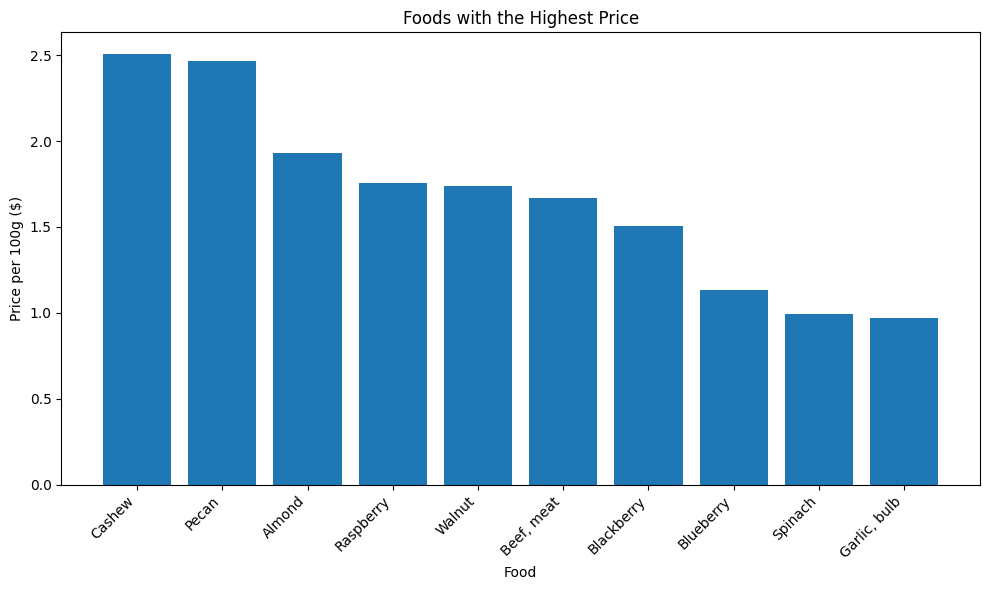

In [146]:
top_prices = combined_with_prices.dropna(
    subset=["price_per_100g"]
).sort_values(
    "price_per_100g",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))
plt.bar(
    top_prices["food_name"],
    top_prices["price_per_100g"]
)
plt.title("Foods with the Highest Price")
plt.xlabel("Food")
plt.ylabel("Price per 100g ($)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

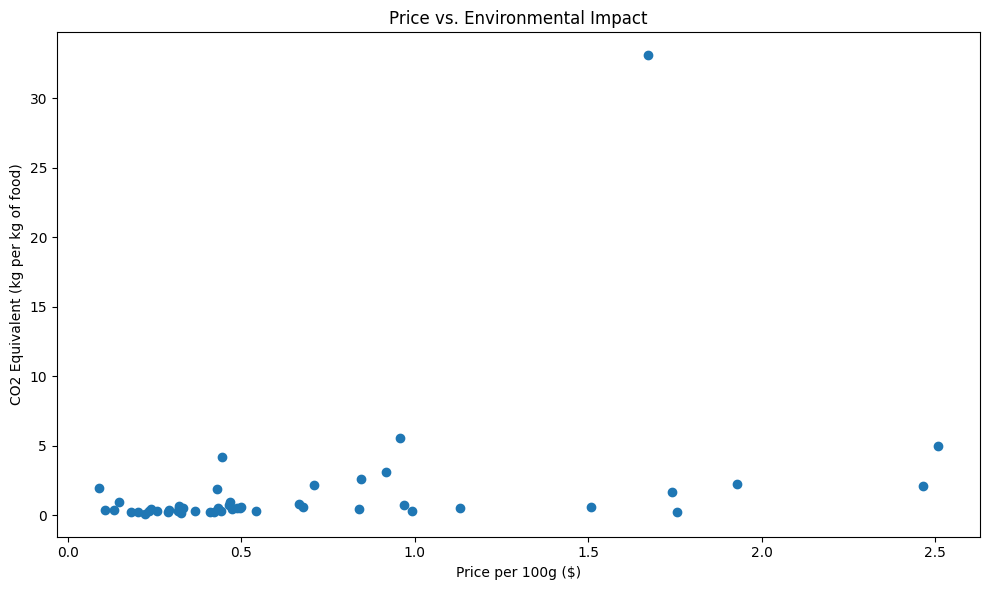

Correlation: 0.3555308920155941


In [147]:
price_environment_data = combined_with_prices.dropna(
    subset=["price_per_100g", "CO2 eq / kg"]
)

plt.figure(figsize=(10, 6))
plt.scatter(
    price_environment_data["price_per_100g"],
    price_environment_data["CO2 eq / kg"]
)
plt.title("Price vs. Environmental Impact")
plt.xlabel("Price per 100g ($)")
plt.ylabel("CO2 Equivalent (kg per kg of food)")
plt.tight_layout()
plt.show()

print(
    "Correlation:",
    price_environment_data["price_per_100g"].corr(
        price_environment_data["CO2 eq / kg"]
    )
)

### Price and Environmental Impact

The correlation between price and environmental impact is 0.36, showing a weak-to-moderate positive relationship. This means that more expensive foods in the dataset tend to have somewhat higher environmental impacts, but the relationship is not strong. There are still many foods that do not follow this pattern. This suggests that cost and environmental impact should be considered as separate factors when creating the meal optimizer rather than assuming that a cheaper food will always have a lower environmental impact.


In [148]:
import os

print(os.listdir("../data/processed"))

['cleaned_environmental.csv', 'cleaned_nutrition.csv', 'combined_food_nutrition_environment.csv', 'combined_food_nutrition_environment_price.csv', 'whole_food_environmental.csv']
